<b><font size="6">Telco Customer Binary Classification</font></b><br><br>

In [2]:
import numpy as np
import pandas as pd
import sklearn as skl
import copy
import warnings
warnings.filterwarnings('ignore')
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score,  recall_score, classification_report,  balanced_accuracy_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier



<b><font size="5">Data access and split</font></b><br><br>

In [8]:
# Setting up a colour scheme for our project
cor = '#815790'

In [9]:
data = pd.read_csv(r"C:\Users\inesb\Downloads\machine_learning_feb2026\WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
x = data.drop(columns=['Churn'], axis=1)
y = data['Churn']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True, stratify=y)
x_train.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35


<b><font size="5">Data exploration</font></b><br><br>

In [14]:
x_train.info()
x_train.describe().T

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 
 1

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5634.0,0.163294,0.369667,0.0,0.0000,0.0,0.0,1.00
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.0,55.0,72.00
MonthlyCharges,5634.0,64.929961,30.138105,18.4,35.6625,70.5,90.0,118.75


In [23]:
columns = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

for val in columns:
    print(data[val].nunique())

7043
2
2
2
2
73
2
3
3
3
3
3
3
3
3
3
2
4
1585
6531
2


,count,mean,std,min,25%,50%,75%,max
age,1545.0,24.344984,6.474498,6.00,20.00,23.0,26.00,88.00
height,1597.0,1.704108,0.095567,1.29,1.63,1.7,1.77,2.19
meals_perday,1602.0,2.684145,0.817584,1.00,3.00,3.0,3.00,4.00
siblings,1599.0,1.500938,1.132562,0.00,0.00,2.0,3.00,3.00
weight,1558.0,86.956354,26.072339,32.00,67.00,83.0,107.00,193.00


----- Understanding Descrete Data -----


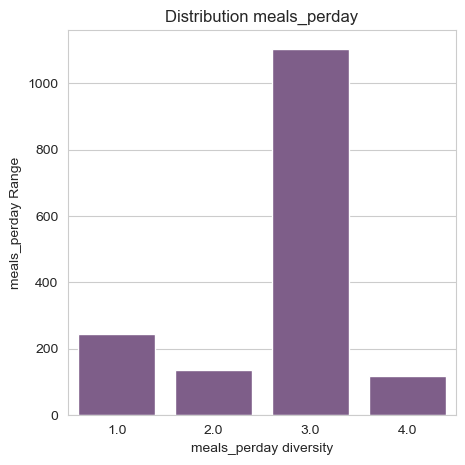

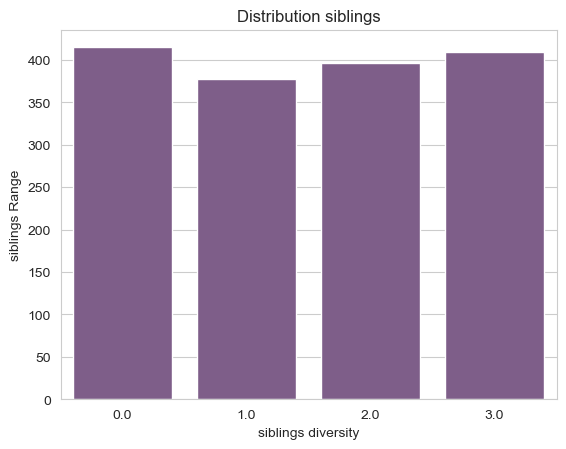

----- Understanding Continuous Data -----


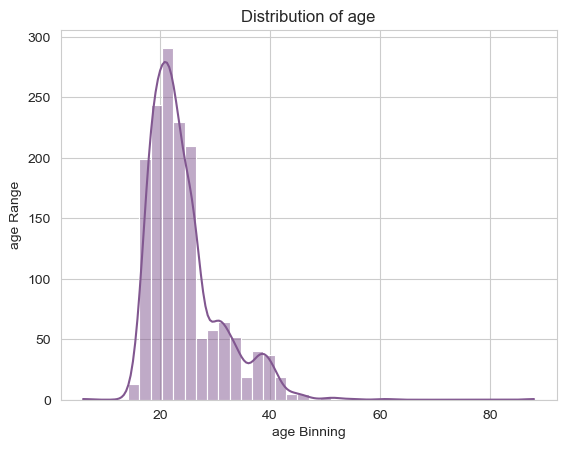

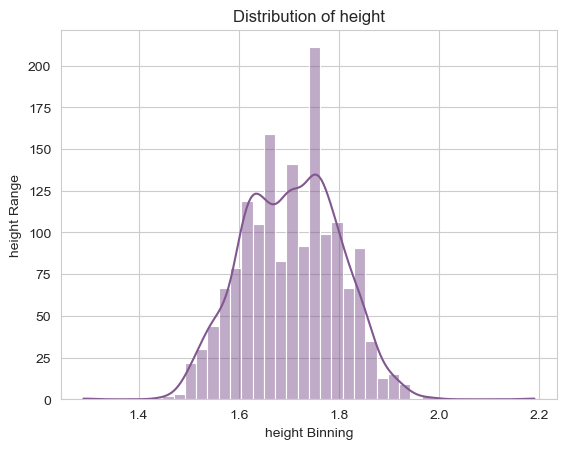

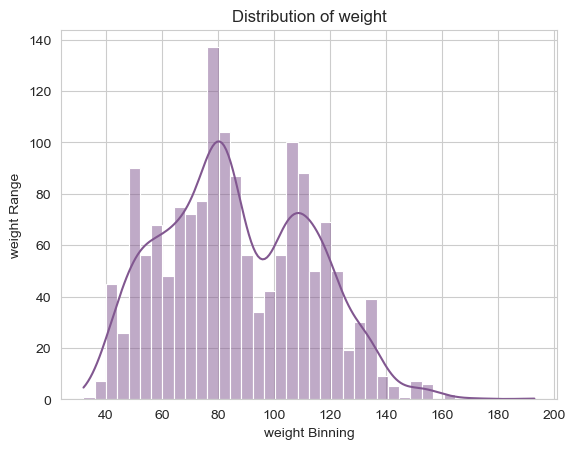

In [ ]:
# Understanding variable distribution
discrete_cols = ['meals_perday', 'siblings']
cont_cols =['age', 'height', 'weight']

# Discrete data- Ordinal (non-continuous)
print('----- Understanding Descrete Data -----')

fig, ax = plt.subplots(figsize= (5,5))
for col in discrete_cols:
    sns.set_style("whitegrid")
    sns.countplot(data= train, x= train[col].dropna(), color= cor)
    plt.title(f'Distribution {col}')
    plt.xlabel(f'{col} diversity')
    plt.ylabel(f'{col} Range')
    plt.show()

# Continuous variables
print('----- Understanding Continuous Data -----')
for col in cont_cols:
    sns.set_style("whitegrid")
    sns.histplot(data= train, x= train[col].dropna(), bins =40, color= cor, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} Binning')
    plt.ylabel(f'{col} Range')
    plt.show()

----- Understanding Categorical Data -----


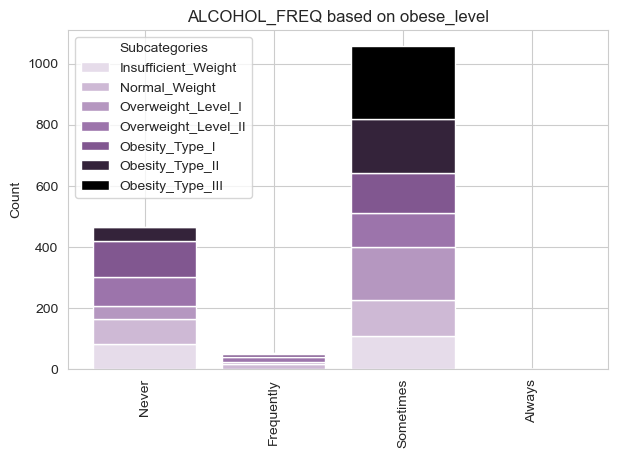

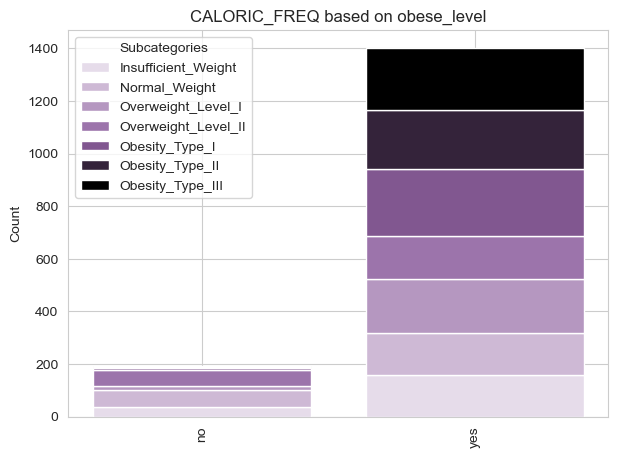

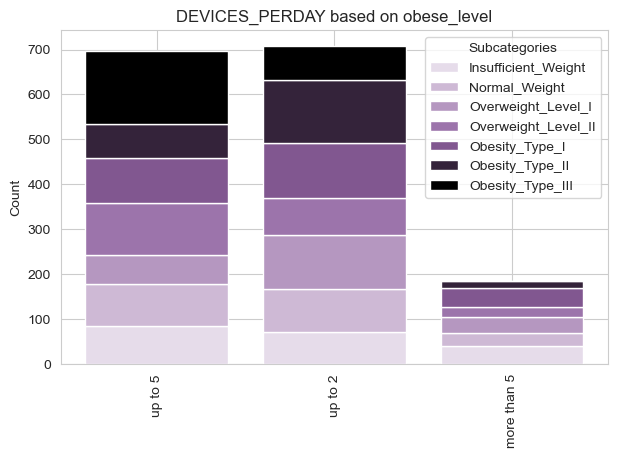

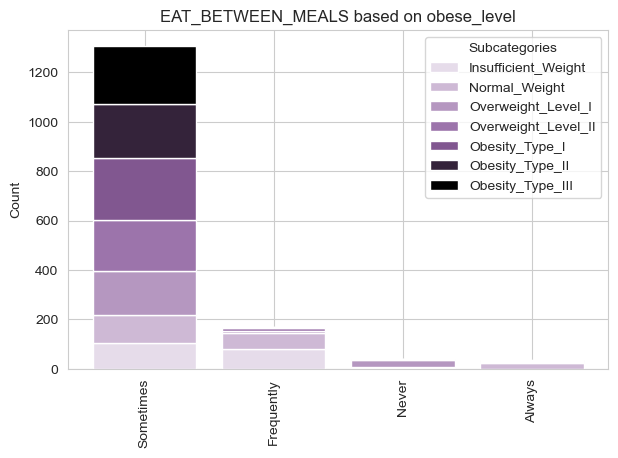

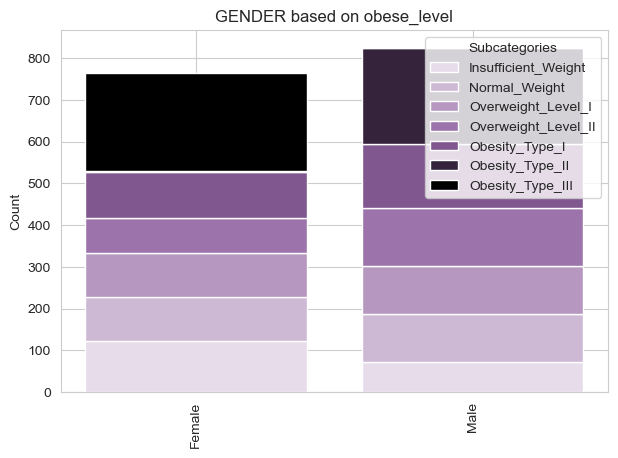

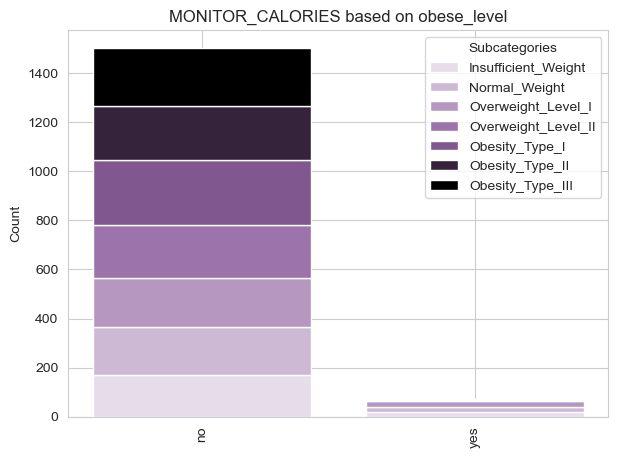

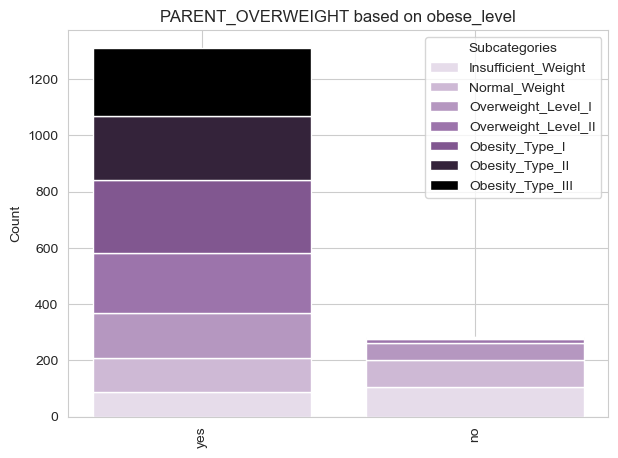

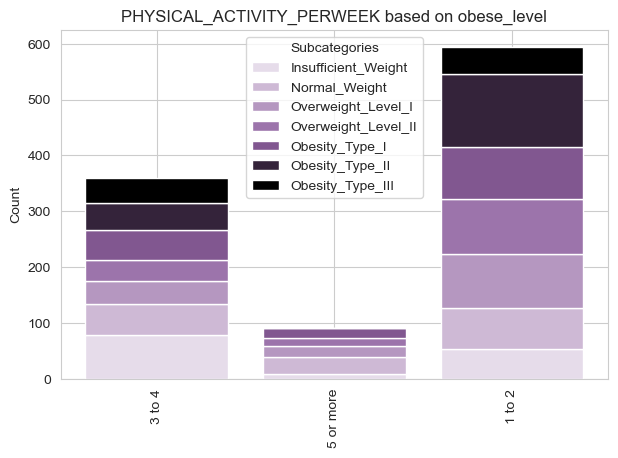

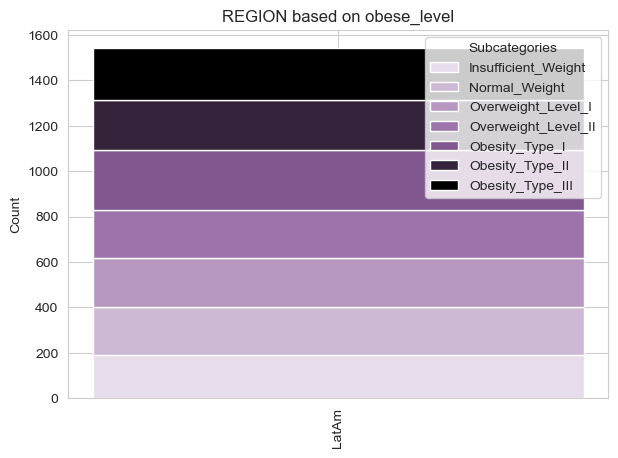

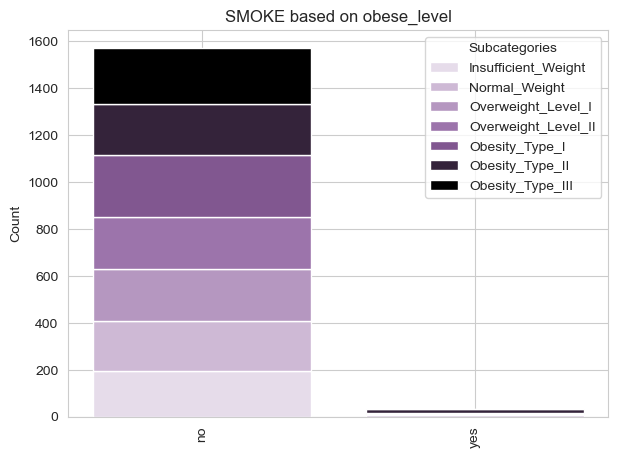

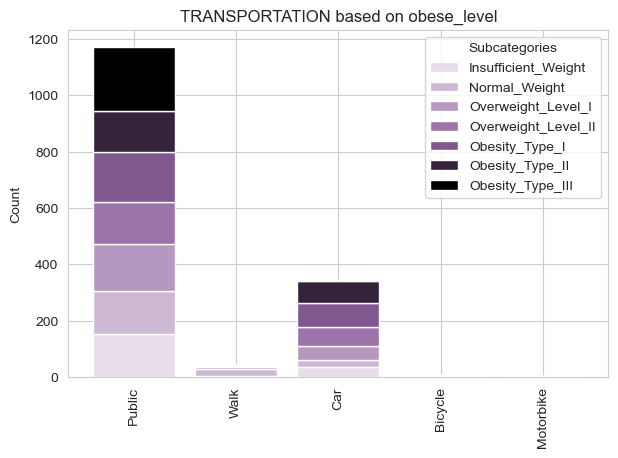

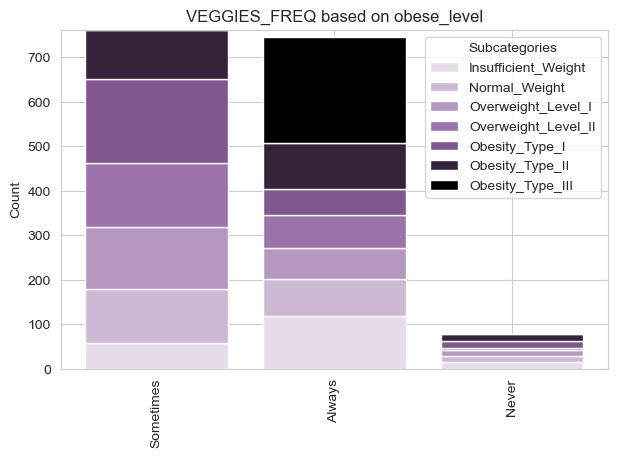

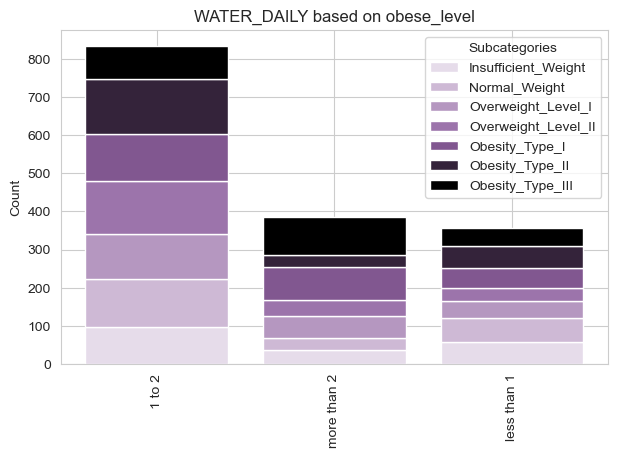

In [36]:
# Understanding Categorical data distribution
print('----- Understanding Categorical Data -----')
def stacked_plot(df, feature, target, stack_cor):
    x_vals = df[feature].dropna().unique()
    subcategories = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Obesity_Type_II',
       'Obesity_Type_III']
    # Manual listing to preserve ordering
    
    log_vals = {val: [
    len(df[(df[feature] == val) & (df[target] == subcategories[i])])
    for i in range(len(subcategories))
    ]
        for val in x_vals
    }
    values = np.array(list(log_vals.values()))
    
    #Plotting a frequency plot
    fig, ax = plt.subplots()
    sns.set_style("whitegrid")
    bottom_values = np.zeros(len(x_vals))

    for i, subcategory in enumerate(subcategories):
        ax.bar(x_vals, values[:, i], bottom=bottom_values, label=subcategory, color= stack_cor[i])
        bottom_values += values[:, i]

    ax.set_ylabel('Count')
    ax.set_title(f'{feature.upper()} based on {target}')
    ax.legend(title='Subcategories')
    plt.xticks(rotation=90)
    fig.tight_layout(h_pad=0.0, pad=1.5)
    plt.show()
    
for feature in train.select_dtypes(include = 'object').drop('obese_level', axis =1):
    stacked_plot(train, feature, 'obese_level', stack_cor)

In [38]:
# Takeaway 2: as a second takeaway, the region var is purely made of 1 value
train.drop('region', axis = 1, inplace= True)

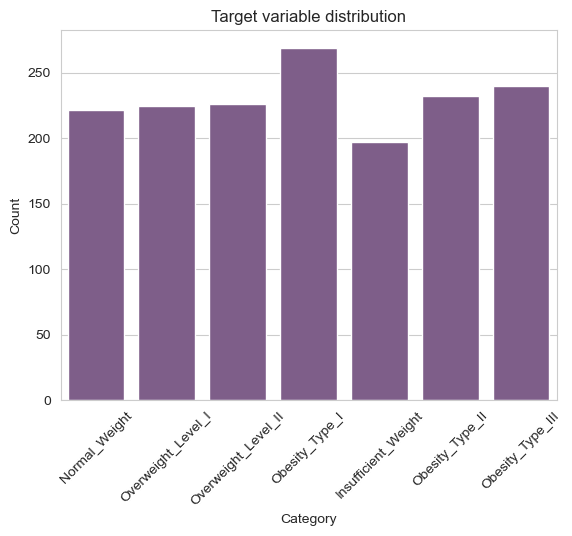

In [40]:
# Understanding target distribution
sns.set_style("whitegrid")
sns.countplot(data= train, x= train['obese_level'].dropna(), color= cor)
plt.title('Target variable distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

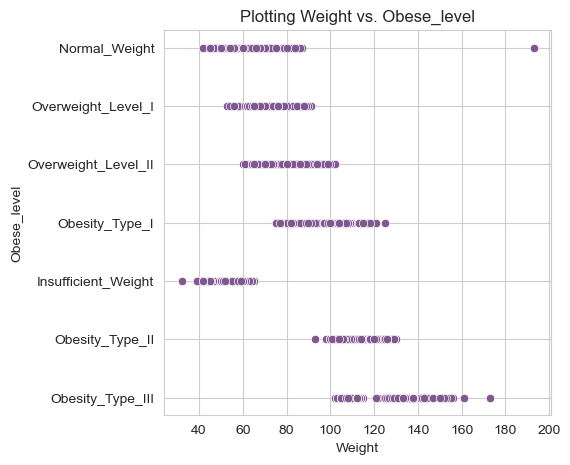

' \nImportant notice. There is a clear outlier in the "normal_weight" category. This matter will be further explored further on.\n'

In [42]:
# Scatter plotting weight and target variable against each other
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=train, x="weight", y='obese_level', color =cor)
plt.title('Plotting Weight vs. Obese_level')
plt.xlabel('Weight')
plt.ylabel('Obese_level')
plt.show()
""" 
Important notice. There is a clear outlier in the "normal_weight" category. This matter will be further explored further on.
"""

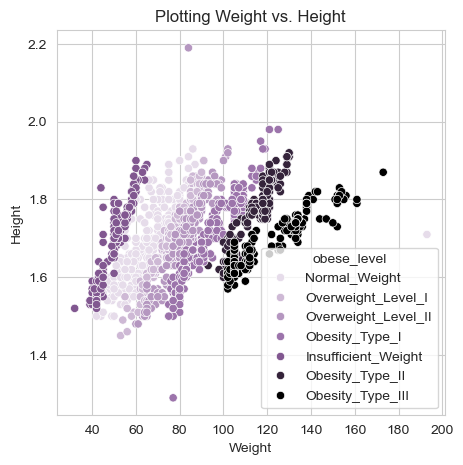

<Figure size 640x480 with 0 Axes>

In [44]:
# Scatter plotting weight and height against each other
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=train, x="weight", y="height", hue= 'obese_level', palette= stack_cor)
plt.title('Plotting Weight vs. Height')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()
plt.savefig("plot_with_params.png", dpi=300, bbox_inches='tight', pad_inches=0.5, transparent=True)
plt.show()

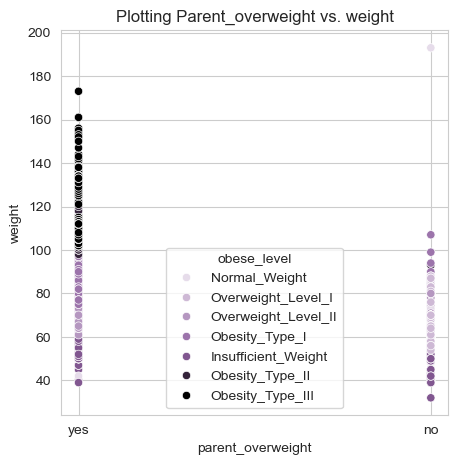

In [46]:
# Plotting parent_overweight and weight variable against each other
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=train, x="parent_overweight", y="weight", hue= 'obese_level', palette= stack_cor)
plt.title('Plotting Parent_overweight vs. weight')
plt.xlabel('parent_overweight')
plt.ylabel('weight')
plt.show()

In [48]:
# Understanding missing values
# As a rule of thumb: avoid imputing more than 5% to avoid overfitting
for col in train.columns:
    missing_values_percent = round((train[col].isnull().sum()/ len(train))*100, 2)
    if missing_values_percent > 3:
        warning = 'WARNING'
    else:
        warning = ''
    print(f'Column {col} with {train[col].isnull().sum()} missing values. ---- {missing_values_percent}% of entries. {warning}')

Column age with 66 missing values. ---- 4.1% of entries. WARNING
Column alcohol_freq with 36 missing values. ---- 2.23% of entries. 
Column caloric_freq with 20 missing values. ---- 1.24% of entries. 
Column devices_perday with 22 missing values. ---- 1.37% of entries. 
Column eat_between_meals with 59 missing values. ---- 3.66% of entries. WARNING
Column gender with 20 missing values. ---- 1.24% of entries. 
Column height with 14 missing values. ---- 0.87% of entries. 
Column meals_perday with 9 missing values. ---- 0.56% of entries. 
Column monitor_calories with 39 missing values. ---- 2.42% of entries. 
Column parent_overweight with 20 missing values. ---- 1.24% of entries. 
Column physical_activity_perweek with 565 missing values. ---- 35.07% of entries. WARNING
Column siblings with 12 missing values. ---- 0.74% of entries. 
Column smoke with 12 missing values. ---- 0.74% of entries. 
Column transportation with 40 missing values. ---- 2.48% of entries. 
Column veggies_freq with 26 

<a class="anchor" id="">

# 3. Modify data (Data preparation)

</a>

<img src="image/step3.png" style="height:60px">

Use this section to apply transformations to your dataset.

Remember that your decisions at this step should be exclusively informed by your **training data**. While you will need to split your data between training and validation, how that split will be made and how to apply the approppriate transformations will depend on the type of model assessment solution you select for your project (each has its own set of advantages and disadvantages that you need to consider). **Please find a list of possible methods for model assessment below**: 

1. **Holdout method**
2. **Repeated Holdout method**
3. **Cross-Validation**

__Note:__ Instead of creating different sections for the treatment of training and validation data, you can make the transformations in the same cell. There is no need to create a specific section for that. 

### 3.1. Data Preparation 

In [50]:
"""
Rationale:
From now on, we should be working only on training data
Thus, we will make the train-test split now
"""
# Data Partitioning
X = train.drop('obese_level', axis=1)
y = train['obese_level']

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size= 0.3,
                                                  random_state = 15,
                                                shuffle = True,
                                                stratify = y
                                            
) 
print(X_train.shape)
print(X_train.info())

(1127, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 1127 entries, 372 to 487
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        1083 non-null   float64
 1   alcohol_freq               1100 non-null   object 
 2   caloric_freq               1110 non-null   object 
 3   devices_perday             1107 non-null   object 
 4   eat_between_meals          1090 non-null   object 
 5   gender                     1113 non-null   object 
 6   height                     1115 non-null   float64
 7   meals_perday               1121 non-null   float64
 8   monitor_calories           1096 non-null   object 
 9   parent_overweight          1111 non-null   object 
 10  physical_activity_perweek  734 non-null    object 
 11  siblings                   1116 non-null   float64
 12  smoke                      1118 non-null   object 
 13  transportation             1095 non-null 

### 3.2. Feature Engineering

#### 3.2.1 Feature Engineering

In [52]:
# Introducing new features
#New feature 1: BMI Score
X_train['BMI'] = X_train['weight'] / X_train['height']**2
X_train['BMI']
"""
Variable: 'BMI'
BMI is used to determine whether an individual has a healthy weight for their height.
This measure will prove itself useful in terms of understanding the corsssssssssssssssssssssrelation between weight and height.
For instance, a person can be very tall, thus, weighting more. Weight itself and height might not be super clear indicators.
"""

"\nVariable: 'BMI'\nBMI is used to determine whether an individual has a healthy weight for their height.\nThis measure will prove itself useful in terms of understanding the corsssssssssssssssssssssrelation between weight and height.\nFor instance, a person can be very tall, thus, weighting more. Weight itself and height might not be super clear indicators.\n"

In [54]:
# Applying the same feature engineering metrics to X val
X_val['BMI'] = X_val['weight'] / X_val['height']**2


#### 3.2.2 Encoding

In [56]:
X_train_encoded = X_train.copy()
"""
Important notice: 
- These encodings were manually coded because sci-kit learn scaling methods do not perform on missing values
- These changes are all fitted to X_Train; and the fittings will be used to transform the validation and testing sets.
-  The values in transportation do not follow a certain order. Thus, an with a basis on variable correlation measures, 
different means of transportation might play a different role in the model outcome
-> We will be working with X_Train further on.

"""
# Transformation 1- Boolean columns ----- > [0, 1]
def bool_set(df, var_col):
    df.loc[df[var_col] =='yes', var_col] = 1
    df.loc[df[var_col] =='no', var_col] = 0
    return df
    
boolean_cols= ['caloric_freq', 'monitor_calories','parent_overweight','smoke']
for col in boolean_cols:
        bool_set(X_train_encoded, col)
    
# Transformation 2 - Boolean columns ----- > [0, 1]
X_train_encoded.loc[X_train_encoded['gender'] =='Female', 'gender'] = 1
X_train_encoded.loc[X_train_encoded['gender'] =='Male', 'gender'] = 0


# Transformation 3 - Encoding categorical variables into ordinal variables
# Encoding multivariable categorical cols (Rank-able)----- > Ordinal scale

#These categorical variables assume a rank, thus we can encode them to an ordinal scale. Tho: maginute might be lost
def ordinal_encoder_ranks(df):
    for col in ['alcohol_freq', 'eat_between_meals']:
        df= df.replace({
            col: {
            'Never':0.0,
            'Sometimes':1.0,
            'Frequently':2.0,
            'Always': 3.0
        }
        })
        
    # Subbing veggies_freq values
    df= df.replace({'veggies_freq': {
        'Never':0.0,
        'Sometimes':1.0,
        'Always':2.0},
                    
        'devices_perday': {
        'up to 2':1.0,
        'up to 5':2.0,
        'more than 5':3.0},
                    
        'water_daily': {
        'less than 1': 1.0,
        '1 to 2':2.0,
        'more than 2':3.0
        },
        'physical_activity_perweek': {
        'None': 0.0,
        '1 to 2': 1.0,
        '3 to 4': 2.0,
        '5 or more':3.0
        }}
        )
    return df

X_train_encoded = ordinal_encoder_ranks(X_train_encoded)

# Transformation 4- Categorical variables ----- > dummy variables
dummy_var_transport= pd.get_dummies(X_train['transportation'], prefix ='transportation_') # fitting dummies to train_test

# Concatenating to a single dataframe, dropping the original transportation column
X_train_encoded= pd.concat([X_train_encoded.drop('transportation', axis =1), dummy_var_transport], axis =1)

In [58]:
display(X_train_encoded)

,age,alcohol_freq,caloric_freq,devices_perday,eat_between_meals,gender,height,meals_perday,monitor_calories,parent_overweight,...,smoke,veggies_freq,water_daily,weight,BMI,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
372,45.0,0.0,1,1.0,2.0,0,1.70,3.0,0,0,...,0,2.0,NaN,86.0,29.757785,False,True,False,False,False
1195,25.0,1.0,1,1.0,1.0,0,1.77,3.0,0,1,...,0,1.0,2.0,114.0,36.388011,False,False,False,True,False
75,22.0,1.0,1,1.0,2.0,1,1.65,4.0,0,1,...,0,2.0,2.0,58.0,21.303949,False,False,False,True,False
1162,27.0,1.0,0,1.0,1.0,0,1.77,3.0,0,1,...,NaN,1.0,2.0,118.0,37.664783,False,True,False,False,False
475,19.0,1.0,1,2.0,2.0,1,1.71,4.0,0,0,...,0,0.0,1.0,50.0,17.099278,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,34.0,0.0,1,1.0,1.0,0,1.71,2.0,0,1,...,0,2.0,1.0,103.0,35.224514,False,False,False,True,False
1160,33.0,0.0,1,1.0,1.0,0,1.70,2.0,0,1,...,0,2.0,1.0,103.0,35.640138,False,False,False,True,False
708,21.0,1.0,1,2.0,1.0,1,1.75,2.0,0,1,...,0,1.0,2.0,78.0,25.469388,False,False,False,True,False


In [60]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1127 entries, 372 to 487
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        1083 non-null   float64
 1   alcohol_freq               1100 non-null   float64
 2   caloric_freq               1110 non-null   object 
 3   devices_perday             1107 non-null   float64
 4   eat_between_meals          1090 non-null   float64
 5   gender                     1113 non-null   object 
 6   height                     1115 non-null   float64
 7   meals_perday               1121 non-null   float64
 8   monitor_calories           1096 non-null   object 
 9   parent_overweight          1111 non-null   object 
 10  physical_activity_perweek  734 non-null    float64
 11  siblings                   1116 non-null   float64
 12  smoke                      1118 non-null   object 
 13  veggies_freq               1110 non-null   float64
 

In [62]:
# Transformation 5. Datatype transformation
def dtype_transformation(df):
    dtype_transformationcols = df.columns.tolist()
    for col in dtype_transformationcols:
        pd.to_numeric(df[col], errors='coerce')
    continuous_cols = ['age', 'height', 'weight', 'BMI']
    dtypes_ ={col : 'float64'
               for col in continuous_cols}
    dtypes_ = {col_:'float16'
               for col_ in dtype_transformationcols if col_ not in continuous_cols
                }
    
    train_dtypes= df.astype(dtypes_)
    return train_dtypes

# Applying transformation to X_train
X_train_encoded = dtype_transformation(X_train_encoded)

In [66]:
# VALIDATION Applying transformations to X_val
X_val_encoded = X_val.copy()
# Transformation 1- Bivariate columns
for col in boolean_cols:
    bool_set(X_val_encoded, col)
    
# Transformation 2 -Assigning gender to boolean var
X_val_encoded.loc[X_val_encoded['gender'] =='Female', 'gender'] = 1
X_val_encoded.loc[X_val_encoded['gender'] =='Male', 'gender'] = 0

# Transformation 3 - Encoding categorical variables into ordinal variables
X_val_encoded = ordinal_encoder_ranks(X_val_encoded)

# Transformation 4- Encoding the transformation column into dummy variables

dummy_var_transport_val= pd.get_dummies(X_val['transportation'], prefix ='transportation_') # fitting dummies to train_test
X_val_encoded= pd.concat([X_val_encoded.drop('transportation', axis =1), dummy_var_transport_val], axis =1)

# Transformation 5 X_val dtype transformation
X_val_encoded = dtype_transformation(X_val_encoded)


In [68]:
# Transformation 6- TARGET variable encoding
encoding_target_variable= {'Insufficient_Weight': 1.0,
        'Normal_Weight': 2.0,
        'Overweight_Level_I' : 3.0,
        'Overweight_Level_II': 4.0,
        'Obesity_Type_I': 5.0,
        'Obesity_Type_II': 6.0,
        'Obesity_Type_III': 7.0}

# Encoding y train
y_train_encoded = y_train.replace(encoding_target_variable)

# VALIDATIONTransformation 6- TARGET variable encoding
y_val_encoded = y_val.replace(encoding_target_variable)

### 3.3. Scaling

In [70]:
"""
X_train bivariate results do not need to be scaled
Reasoning: as they can only produce 2 values, the results would prove to be absolutely rendudant to our model
Variables: 'caloric_freq', 'gender', 'monitor_calories','parent_overweight','smoke' + Variables related to transportation
"""
# Robust Scaler for continuous variables: age, height, weight, BMI
rbst_scaler_cols = ['age', 'alcohol_freq', 'devices_perday',
       'eat_between_meals', 'height', 'meals_perday',
                    'parent_overweight', 'physical_activity_perweek',
       'siblings', 'veggies_freq', 'water_daily', 'weight', 'BMI']

robust_scaler = RobustScaler().fit(X_train_encoded[rbst_scaler_cols])
# Transforming training data
X_train_scaled_rbst = robust_scaler.transform(X_train_encoded[rbst_scaler_cols])
X_train_scaled_rbst = pd.DataFrame(X_train_scaled_rbst, columns=rbst_scaler_cols).set_index(X_train_encoded.index)

#Combining into a single dataframe
X_train_scaled = pd.concat([X_train_scaled_rbst, X_train_encoded.drop(rbst_scaler_cols, axis =1)], axis =1)
display(X_train_scaled)


# VALIDATION Applying same transformations into validation set
#Combining into a dataframe
X_val_scaled_rbst = robust_scaler.transform(X_val_encoded[rbst_scaler_cols])
X_val_scaled_rbst = pd.DataFrame(X_val_scaled_rbst, columns=rbst_scaler_cols).set_index(X_val_encoded.index)

#Combining into a single dataframe
X_val_scaled = pd.concat([X_val_scaled_rbst, X_val_encoded.drop(rbst_scaler_cols, axis =1)], axis =1)
display(X_val_scaled)

,age,alcohol_freq,devices_perday,eat_between_meals,height,meals_perday,parent_overweight,physical_activity_perweek,siblings,veggies_freq,...,BMI,caloric_freq,gender,monitor_calories,smoke,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
372,3.666667,-1.0,-1.0,1.0,-0.071429,0.0,-1.0,NaN,-0.166667,1.0,...,0.092120,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1195,0.333333,0.0,-1.0,0.0,0.428571,0.0,0.0,1.0,-0.166667,0.0,...,0.680501,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75,-0.166667,0.0,-1.0,1.0,-0.428571,1.0,0.0,0.0,-0.500000,1.0,...,-0.658092,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1162,0.666667,0.0,-1.0,0.0,0.428571,0.0,0.0,0.0,0.500000,0.0,...,0.793805,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0
475,-0.666667,0.0,0.0,1.0,0.000000,1.0,-1.0,1.0,-0.166667,-1.0,...,-1.031224,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,1.833333,-1.0,-1.0,0.0,0.000000,-1.0,0.0,1.0,-0.500000,1.0,...,0.577250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1160,1.666667,-1.0,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.500000,1.0,...,0.614133,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
708,-0.333333,0.0,0.0,0.0,0.285714,-1.0,0.0,0.0,-0.500000,0.0,...,-0.288442,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,age,alcohol_freq,devices_perday,eat_between_meals,height,meals_perday,parent_overweight,physical_activity_perweek,siblings,veggies_freq,...,BMI,caloric_freq,gender,monitor_calories,smoke,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
713,0.000000,0.0,1.0,0.0,-0.071429,0.0,0.0,0.0,-0.500000,0.0,...,-0.245653,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1223,0.166667,NaN,-1.0,0.0,0.500000,0.0,0.0,0.0,-0.166667,1.0,...,0.784363,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1167,1.333333,0.0,0.0,0.0,0.285714,0.0,0.0,0.0,0.500000,1.0,...,0.928594,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1221,1.500000,-1.0,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.166667,1.0,...,0.614133,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
298,-0.833333,-1.0,1.0,1.0,0.357143,0.0,-1.0,1.0,0.166667,1.0,...,-0.543243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,0.166667,0.0,1.0,0.0,1.071429,-1.0,0.0,0.0,0.166667,-1.0,...,-0.086155,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1393,0.500000,0.0,0.0,0.0,-0.428571,0.0,0.0,NaN,-0.500000,1.0,...,0.873913,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1461,-0.666667,0.0,0.0,0.0,0.071429,0.0,0.0,0.0,0.500000,1.0,...,1.290925,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 3.3.1 Outlier Treatment

Column: age
There are outliers in this column.


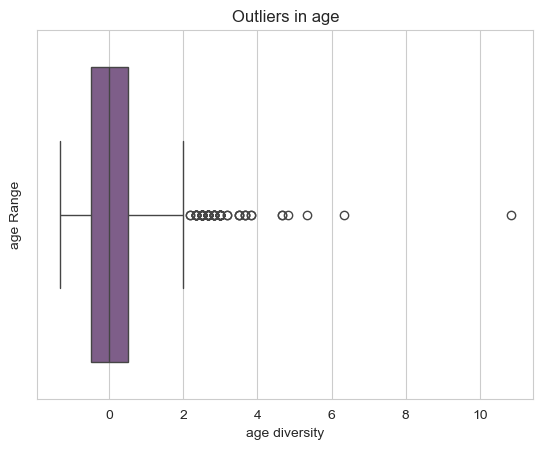

Column: alcohol_freq
There are NO outliers in this column.

Column: devices_perday
There are NO outliers in this column.

Column: eat_between_meals
There are outliers in this column.


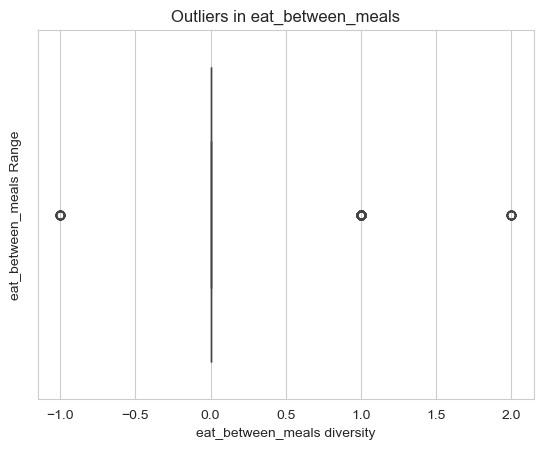

Column: height
There are outliers in this column.


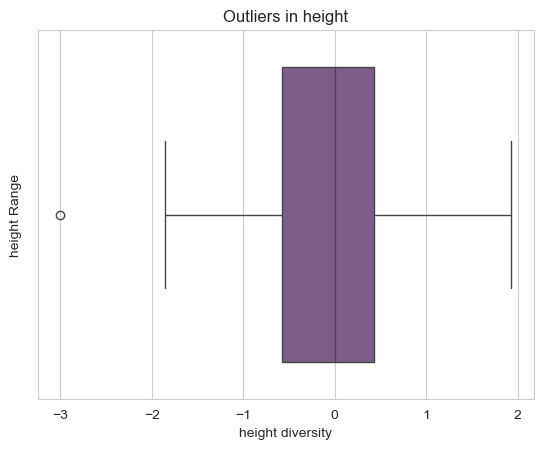

Column: meals_perday
There are NO outliers in this column.

Column: parent_overweight
There are outliers in this column.


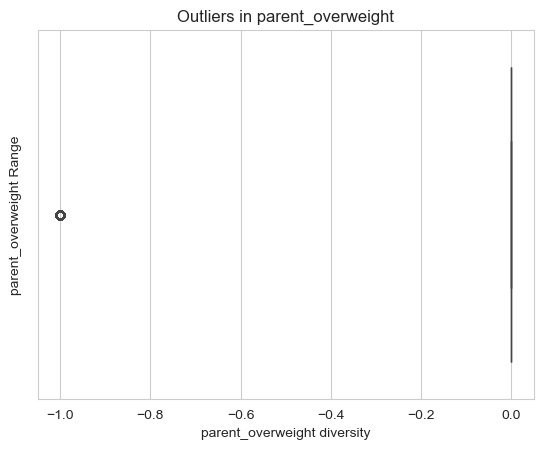

Column: physical_activity_perweek
There are NO outliers in this column.

Column: siblings
There are NO outliers in this column.

Column: veggies_freq
There are NO outliers in this column.

Column: water_daily
There are outliers in this column.


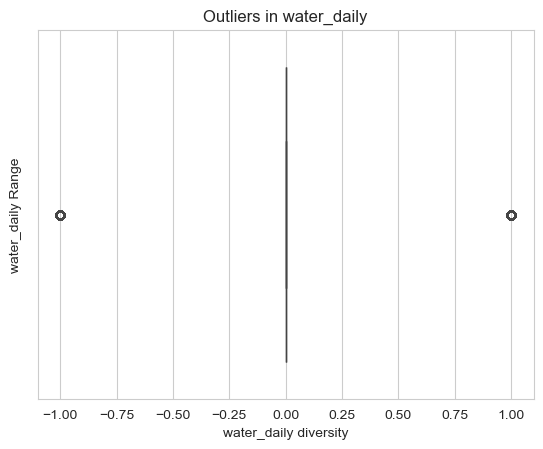

Column: weight
There are outliers in this column.


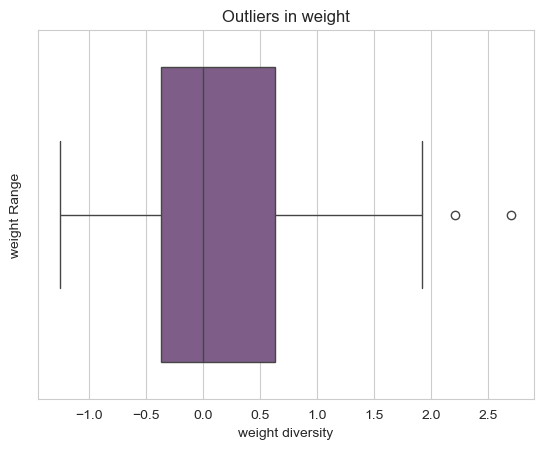

Column: BMI
There are outliers in this column.


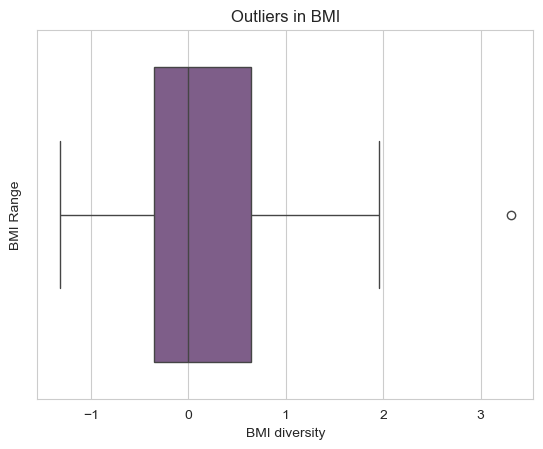

Column: caloric_freq
There are outliers in this column.


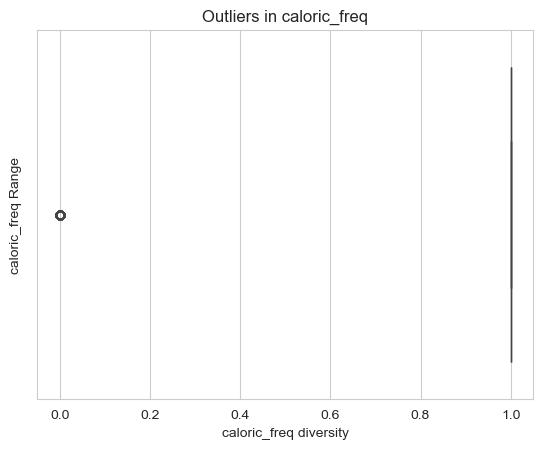

Column: gender
There are NO outliers in this column.

Column: monitor_calories
There are outliers in this column.


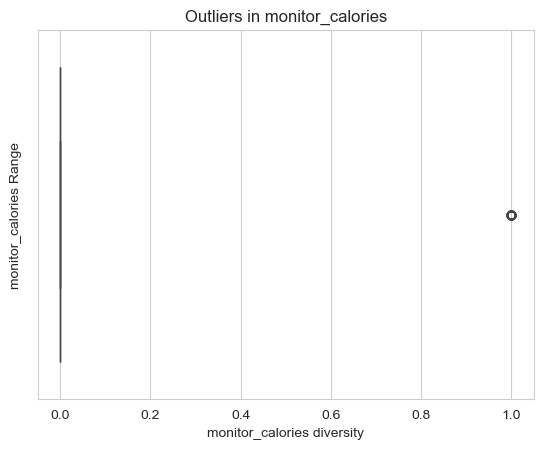

Column: smoke
There are outliers in this column.


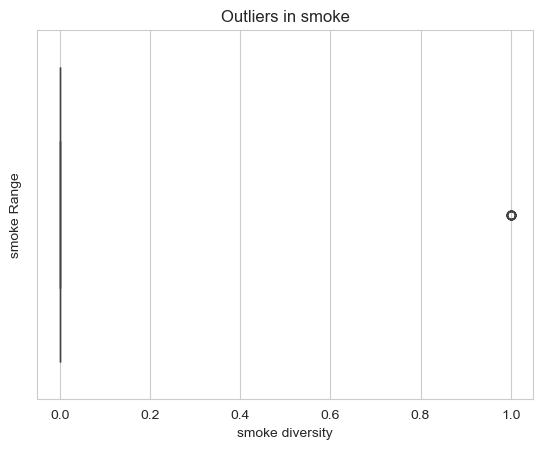

Column: transportation__Bicycle
There are outliers in this column.


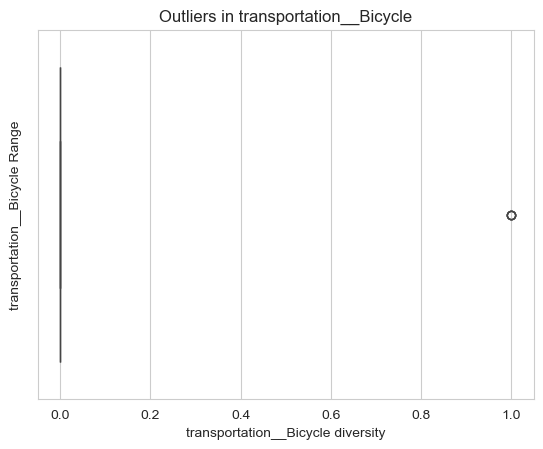

Column: transportation__Car
There are outliers in this column.


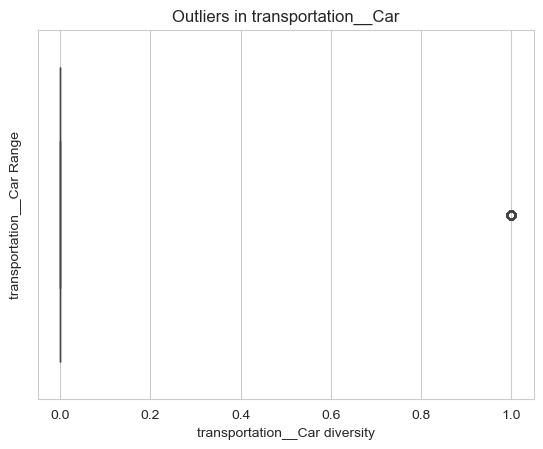

Column: transportation__Motorbike
There are outliers in this column.


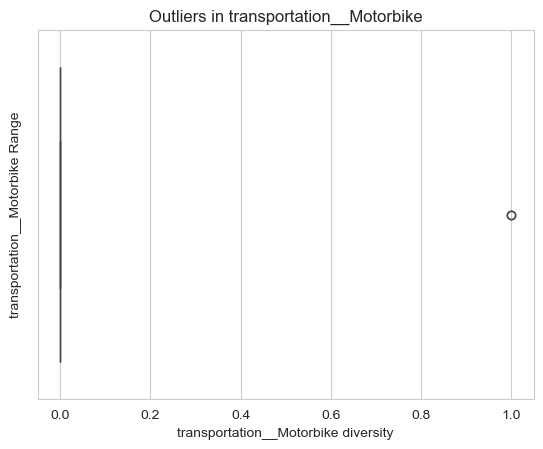

Column: transportation__Public
There are NO outliers in this column.

Column: transportation__Walk
There are outliers in this column.


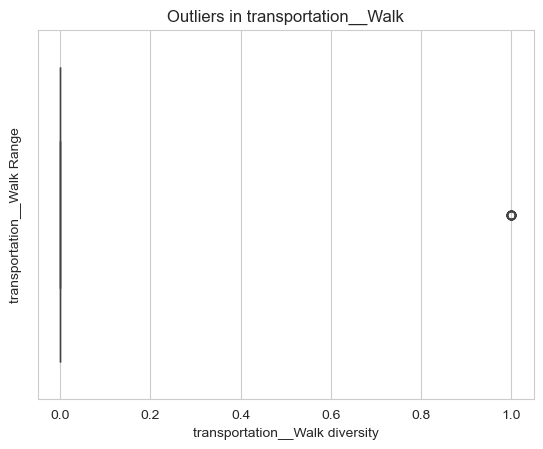

--- Analysis : Columns prone to outlier treatment ---
['age', 'eat_between_meals', 'height', 'parent_overweight', 'water_daily', 'weight', 'BMI', 'caloric_freq', 'monitor_calories', 'smoke', 'transportation__Bicycle', 'transportation__Car', 'transportation__Motorbike', 'transportation__Walk']


In [72]:
#Does outlier removal make sense? 
"""
We will now conduct some statistical tests to understand if the outliers play an important part in the target val or not
Practice: Understanding outliers in our dataset - Exploration
"""
#Outlier exploration
def outliers_left(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    IQR = q3 - q1
    outliers_left = q1 - 1.5 * IQR
    return outliers_left
    
def outliers_right(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    IQR = q3 - q1
    outliers_right = q3 + 1.5 * IQR
    return outliers_right

outlier_treatment_cols = []

for col in X_train_scaled.columns:
    outlier_left = outliers_left(X_train_scaled[col])
    outlier_right = outliers_right(X_train_scaled[col])
    outliers = X_train_scaled[(X_train_scaled[col] <= outlier_left) | (X_train_scaled[col] >= outlier_right)]
    print(f"Column: {col}")
    if not outliers.empty:
        print("There are outliers in this column.")
        sns.boxplot(data= X_train_scaled, x= X_train_scaled[X_train_scaled[col].notna()][col], color= cor)
        plt.title(f'Outliers in {col}')
        plt.xlabel(f'{col} diversity')
        plt.ylabel(f'{col} Range')
        plt.show()
        outlier_treatment_cols.append(col)
        #print(train[col].value_counts())
    else:
        print("There are NO outliers in this column.")
        print()
print('--- Analysis : Columns prone to outlier treatment ---')
print(outlier_treatment_cols)


#### All outlier prone measures taken into account:
<p> -- > The variables [age, height, weight, BMI] are prone to outliers, yet, as studied further on, they are important for target prediction. Check section: 3.4 Feature Selection -> Filter Methods <b>Conclusion: Those outliers can prove themselves to be key indicators in target prediction; thus those variables will not be treated in this step.</b></p>
<p> -- > As for the variables [transportation__Bicycle, transportation__Motorbike, transportation__Walk, smoke,transportation__Car, water_daily], they present very low variability. They will be further eliminated in the section 3.4 Feature Selection. <b>Conclusion: those variables will not be eliminated in this step.</b></p>
<p> -- > The remaining variables, prior to imputation, are ordinal/ categorial variables and the unitary difference between values is related to the encoding. <b>Conclusion: These variables present very low variability and will be further analysed.</b></p>

BEFORE OUTLIER TREATMENT


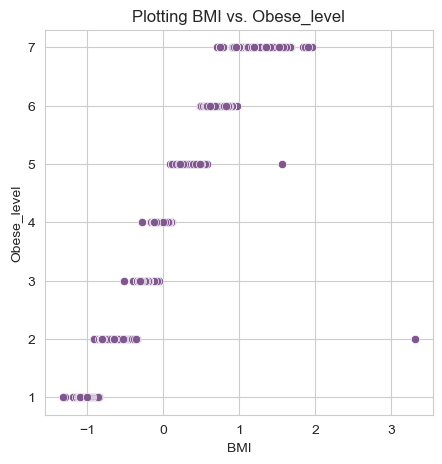

AFTER OUTLIER TREATMENT
----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 2.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 3.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 4.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 5.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 6.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 7.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.


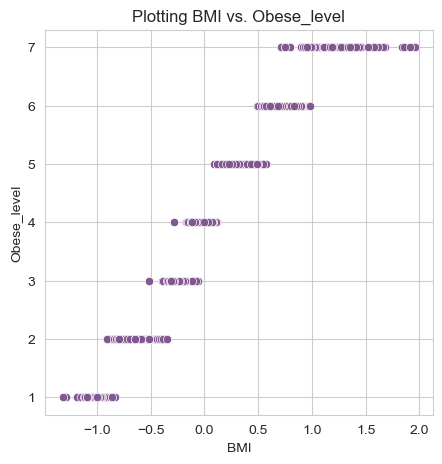

----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 2.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 3.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 4.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 5.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 6.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 7.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.


,age,alcohol_freq,devices_perday,eat_between_meals,height,meals_perday,parent_overweight,physical_activity_perweek,siblings,veggies_freq,...,BMI,caloric_freq,gender,monitor_calories,smoke,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
372,3.666667,-1.0,-1.0,1.0,-0.071429,0.0,-1.0,NaN,-0.166667,1.0,...,0.092120,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1195,0.333333,0.0,-1.0,0.0,0.428571,0.0,0.0,1.0,-0.166667,0.0,...,0.680501,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75,-0.166667,0.0,-1.0,1.0,-0.428571,1.0,0.0,0.0,-0.500000,1.0,...,-0.658092,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1162,0.666667,0.0,-1.0,0.0,0.428571,0.0,0.0,0.0,0.500000,0.0,...,0.793805,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0
475,-0.666667,0.0,0.0,1.0,0.000000,1.0,-1.0,1.0,-0.166667,-1.0,...,-1.031224,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,1.833333,-1.0,-1.0,0.0,0.000000,-1.0,0.0,1.0,-0.500000,1.0,...,0.577250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1160,1.666667,-1.0,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.500000,1.0,...,0.614133,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
708,-0.333333,0.0,0.0,0.0,0.285714,-1.0,0.0,0.0,-0.500000,0.0,...,-0.288442,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 2.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 3.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 4.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 5.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 6.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 7.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.


id
372     4.0
1195    6.0
75      2.0
1162    6.0
475     1.0
       ... 
1368    6.0
1160    6.0
708     3.0
641     3.0
487     1.0
Name: obese_level, Length: 1125, dtype: float64

In [74]:
# As previously stated. There is a clear outlier in the "normal_weight" category, but perhaps it would be a more relevant measure to dealt with the BMI variable
# Scatter plotting BMI and target variable against each other
print(f'BEFORE OUTLIER TREATMENT')
X_train_support = pd.concat([X_train_scaled, y_train_encoded], axis=1)
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=X_train_support, x="BMI", y='obese_level', color =cor)
plt.title('Plotting BMI vs. Obese_level')
plt.xlabel('BMI')
plt.ylabel('Obese_level')
plt.show()

"""
Defining class thresholds;
thresholds = {
        1.0: [-1.5, -0.25],
        2.0: [-1.0, 0.25],
        3.0: [-0.8, 0.25],
        4.0: [-0.6, 0.6],
        5.0: [-0.3, 1.0],
        6.0: [0.25, 1.25],
        7.0: [0.4, 2.5]}
"""
def obese_filter_threshold(df, y): # if flag is True: dropping indexes on df
    temp= pd.concat([df, y], axis=1)
    thresholds = {
        1.0: [-1.5, -0.25],
        2.0: [-1.0, 0.25],
        3.0: [-0.8, 0.25],
        4.0: [-0.6, 0.6],
        5.0: [-0.3, 1.0],
        6.0: [0.25, 1.25],
        7.0: [0.4, 2.5]}
    for level in list(thresholds.keys()):
        print(f'----- {level} LEVEL -----')
        # checking for violations
        df_violated= temp[(temp['obese_level']== level) & 
        ((temp['BMI']< thresholds[level][0]) | (temp['BMI']> thresholds[level][1]))]
        index_remove = list(df_violated.index)
        
        print(f'{len(index_remove)} inadequate datatypes ----> Up for removal.')
        temp= temp.drop(index = index_remove) 
    return temp
        
print(f'AFTER OUTLIER TREATMENT')
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=  obese_filter_threshold(X_train_scaled, y_train_encoded), x="BMI", y='obese_level', color =cor)
plt.title('Plotting BMI vs. Obese_level')
plt.xlabel('BMI')
plt.ylabel('Obese_level')
plt.show()

X_train_clean =  obese_filter_threshold(X_train_scaled, y_train_encoded).drop('obese_level', axis =1)
display(X_train_clean)
y_train_clean = obese_filter_threshold(X_train_scaled, y_train_encoded)['obese_level']
display(y_train_clean)

----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 2.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 3.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 4.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 5.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 6.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 7.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 2.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 3.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 4.0 LEVEL -----
1 inadequate datatypes ----> Up for removal.
----- 5.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 6.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 7.0 LEVEL -----
0 inadequate datatypes ----> Up for removal.
----- 1.0 LEVEL -----
0 inadequate datatypes ----> Up for remo

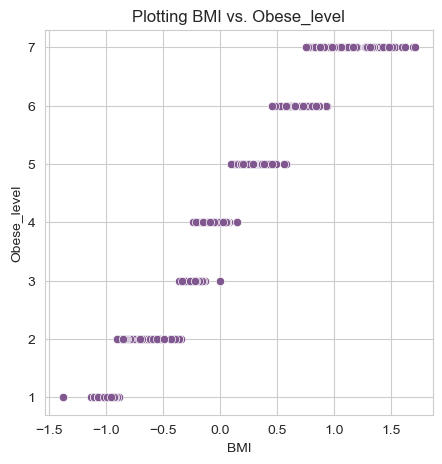

In [76]:
# Outlier correction to X_val 
X_val_clean =  obese_filter_threshold(X_val_scaled, y_val_encoded).drop('obese_level', axis =1)
y_val_clean = obese_filter_threshold(X_val_scaled, y_val_encoded)['obese_level']

#Plot
fig, ax = plt.subplots(figsize= (5,5))
sns.set_style("whitegrid")
sns.scatterplot(data=  obese_filter_threshold(X_val_scaled, y_val_encoded), x="BMI", y='obese_level', color =cor)
plt.title('Plotting BMI vs. Obese_level')
plt.xlabel('BMI')
plt.ylabel('Obese_level')
plt.show()

### 3.1.2 Imputation

In [80]:
""" 
As prior understood in the data exploration segment:
Due to sci-kit learn constraints we have opted to impute all missing values resorting to KNN
"""
# Getting the most optimal number of clusters
# Replacing missing values with the median value for model optimization
X_train_median = X_train_clean.copy()
X_train_median = X_train_median.fillna(X_train_median.median())

X_val_median = X_val_clean.copy()
X_val_median = X_val_median.fillna(X_val_median.median())

numberK_list=np.arange(1,21)
high_score=0
nof=0          
score_list_train =[]
score_list_val =[]
for n in numberK_list:
    model = KNeighborsClassifier(n_neighbors = n).fit(X_train_median, y_train_clean)
    score_train = model.score(X_train_median, y_train_clean)
    score_val = model.score(X_val_median, y_val_clean)
    score_list_train.append(score_train)
    score_list_val.append(score_val)

    if(score_val>high_score):
        high_score = score_val
        nof = numberK_list[n-1]
#print(score_list_val)
print("Best number of neighbors: %d" %nof)
print("Mean accuracy in train with %d neighbors: %f" % (nof, score_list_train[nof-1]))
print("Mean accuracy in validation with %d neighbors: %f" % (nof, high_score))

  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best number of neighbors: 1
Mean accuracy in train with 1 neighbors: 1.000000
Mean accuracy in validation with 1 neighbors: 0.824017


In [82]:
"""
Based on prior conclusions, we will be following with k=1.
"""
imputer_Xtrain = KNNImputer(n_neighbors = 1).fit(X_train_clean)

X_train_imputed= pd.DataFrame(imputer_Xtrain.transform(X_train_clean), index= X_train_clean.index,
                                   columns = X_train_clean.columns)
display(X_train_imputed)
display(X_train_imputed.info())

,age,alcohol_freq,devices_perday,eat_between_meals,height,meals_perday,parent_overweight,physical_activity_perweek,siblings,veggies_freq,...,BMI,caloric_freq,gender,monitor_calories,smoke,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
372,3.666667,-1.0,-1.0,1.0,-0.071429,0.0,-1.0,0.0,-0.166667,1.0,...,0.092120,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1195,0.333333,0.0,-1.0,0.0,0.428571,0.0,0.0,1.0,-0.166667,0.0,...,0.680501,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75,-0.166667,0.0,-1.0,1.0,-0.428571,1.0,0.0,0.0,-0.500000,1.0,...,-0.658092,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1162,0.666667,0.0,-1.0,0.0,0.428571,0.0,0.0,0.0,0.500000,0.0,...,0.793805,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
475,-0.666667,0.0,0.0,1.0,0.000000,1.0,-1.0,1.0,-0.166667,-1.0,...,-1.031224,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,1.833333,-1.0,-1.0,0.0,0.000000,-1.0,0.0,1.0,-0.500000,1.0,...,0.577250,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1160,1.666667,-1.0,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.500000,1.0,...,0.614133,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
708,-0.333333,0.0,0.0,0.0,0.285714,-1.0,0.0,0.0,-0.500000,0.0,...,-0.288442,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 1125 entries, 372 to 487
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        1125 non-null   float64
 1   alcohol_freq               1125 non-null   float64
 2   devices_perday             1125 non-null   float64
 3   eat_between_meals          1125 non-null   float64
 4   height                     1125 non-null   float64
 5   meals_perday               1125 non-null   float64
 6   parent_overweight          1125 non-null   float64
 7   physical_activity_perweek  1125 non-null   float64
 8   siblings                   1125 non-null   float64
 9   veggies_freq               1125 non-null   float64
 10  water_daily                1125 non-null   float64
 11  weight                     1125 non-null   float64
 12  BMI                        1125 non-null   float64
 13  caloric_freq               1125 non-null   float64
 

None

In [84]:
# VALIDATION Repeating the same procedure in the X_val dataset
# Based on x_train fitting --- > imputer_Xtrain
X_val_imputed= pd.DataFrame(imputer_Xtrain.transform(X_val_clean), index= X_val_clean.index,
                                   columns = X_val_clean.columns)

### 3.4. Feature Selection

#### Filter Methods

In [86]:
""" 
Filter Count
We will create a dictionary to store the count strikes on feature removal, per variable.
""" 
filter_dic = {key: 'No' for key in X_train_imputed.columns}
#print(filter_dic)

##### Low-variance variables

In [88]:
univariate_dic =filter_dic.copy()
X_train_variances= X_train_imputed.var().sort_values()

# Variance close to zero. Less than 0.1
for key in X_train_variances[X_train_variances.abs() <0.1].index:
    univariate_dic[key] = 'Yes'
print(X_train_variances)
#print(univariate_dic)

transportation__Motorbike    0.001776
transportation__Bicycle      0.003546
smoke                        0.020044
transportation__Walk         0.023445
monitor_calories             0.042507
caloric_freq                 0.095374
siblings                     0.139902
parent_overweight            0.150839
transportation__Car          0.165401
transportation__Public       0.195730
eat_between_meals            0.196599
gender                       0.249534
alcohol_freq                 0.260400
veggies_freq                 0.338051
physical_activity_perweek    0.381411
weight                       0.417316
devices_perday               0.459616
height                       0.459845
water_daily                  0.467260
BMI                          0.496430
meals_perday                 0.694531
age                          1.218889
dtype: float64


##### Statistical Correlations

SPEARMAN correlation.


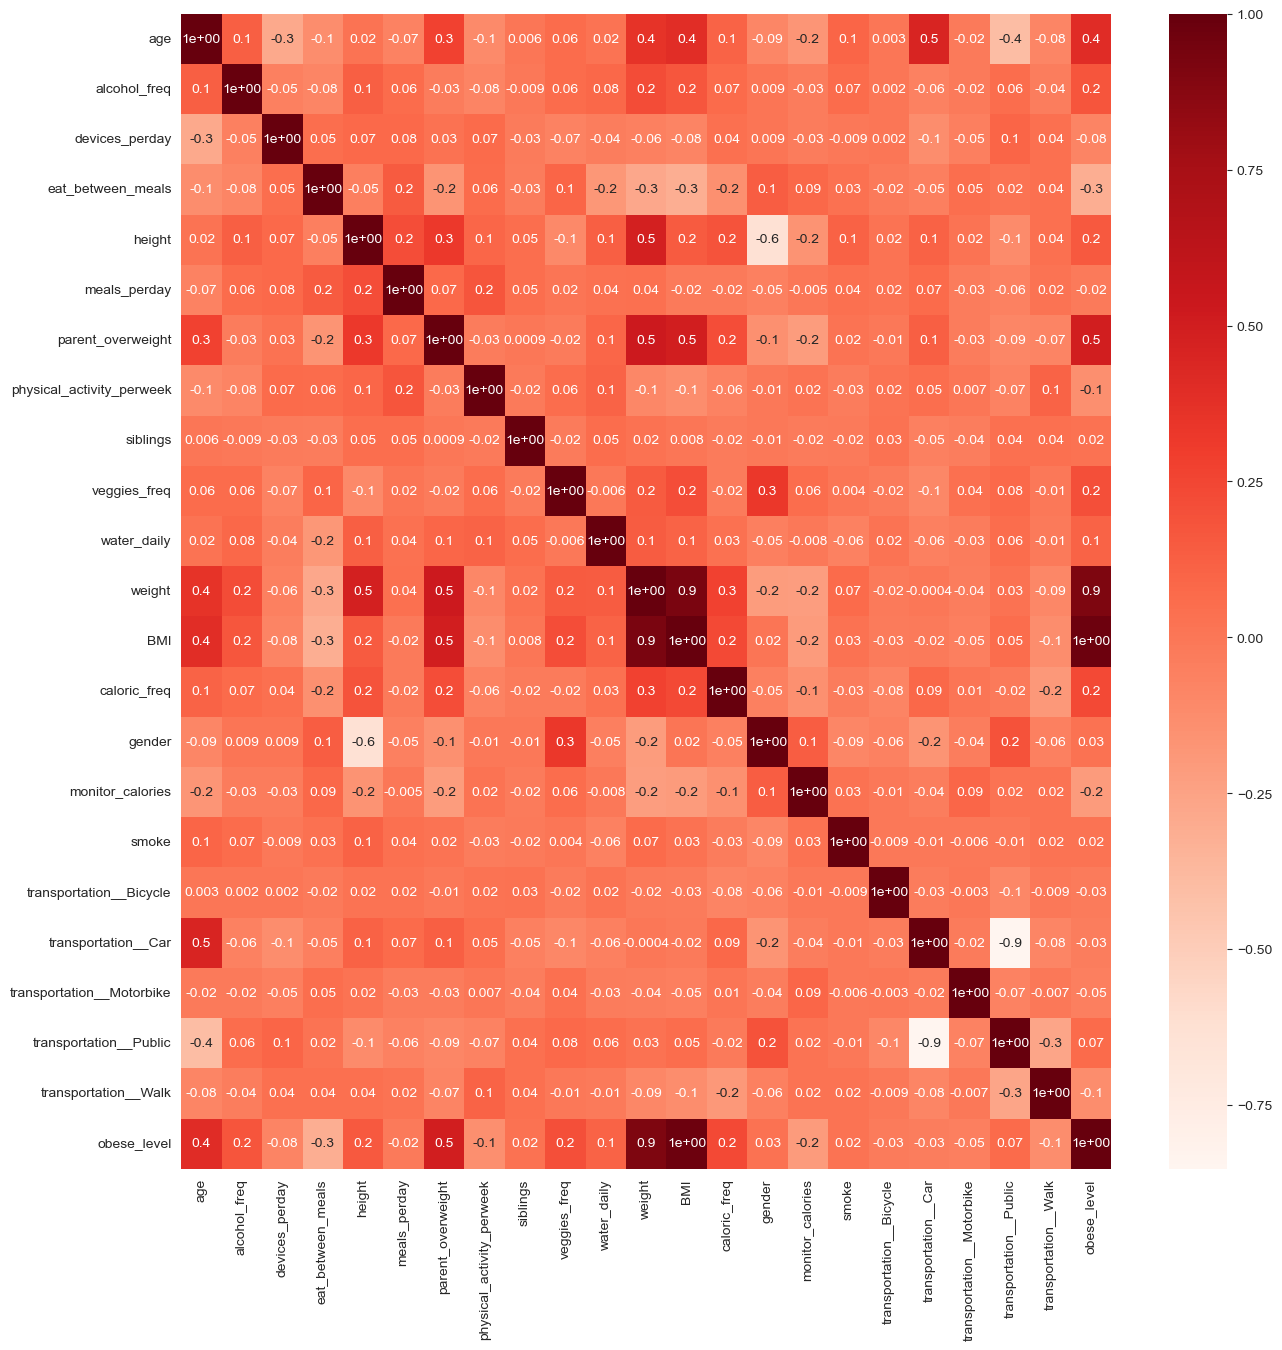

None

PEARSON correlation.


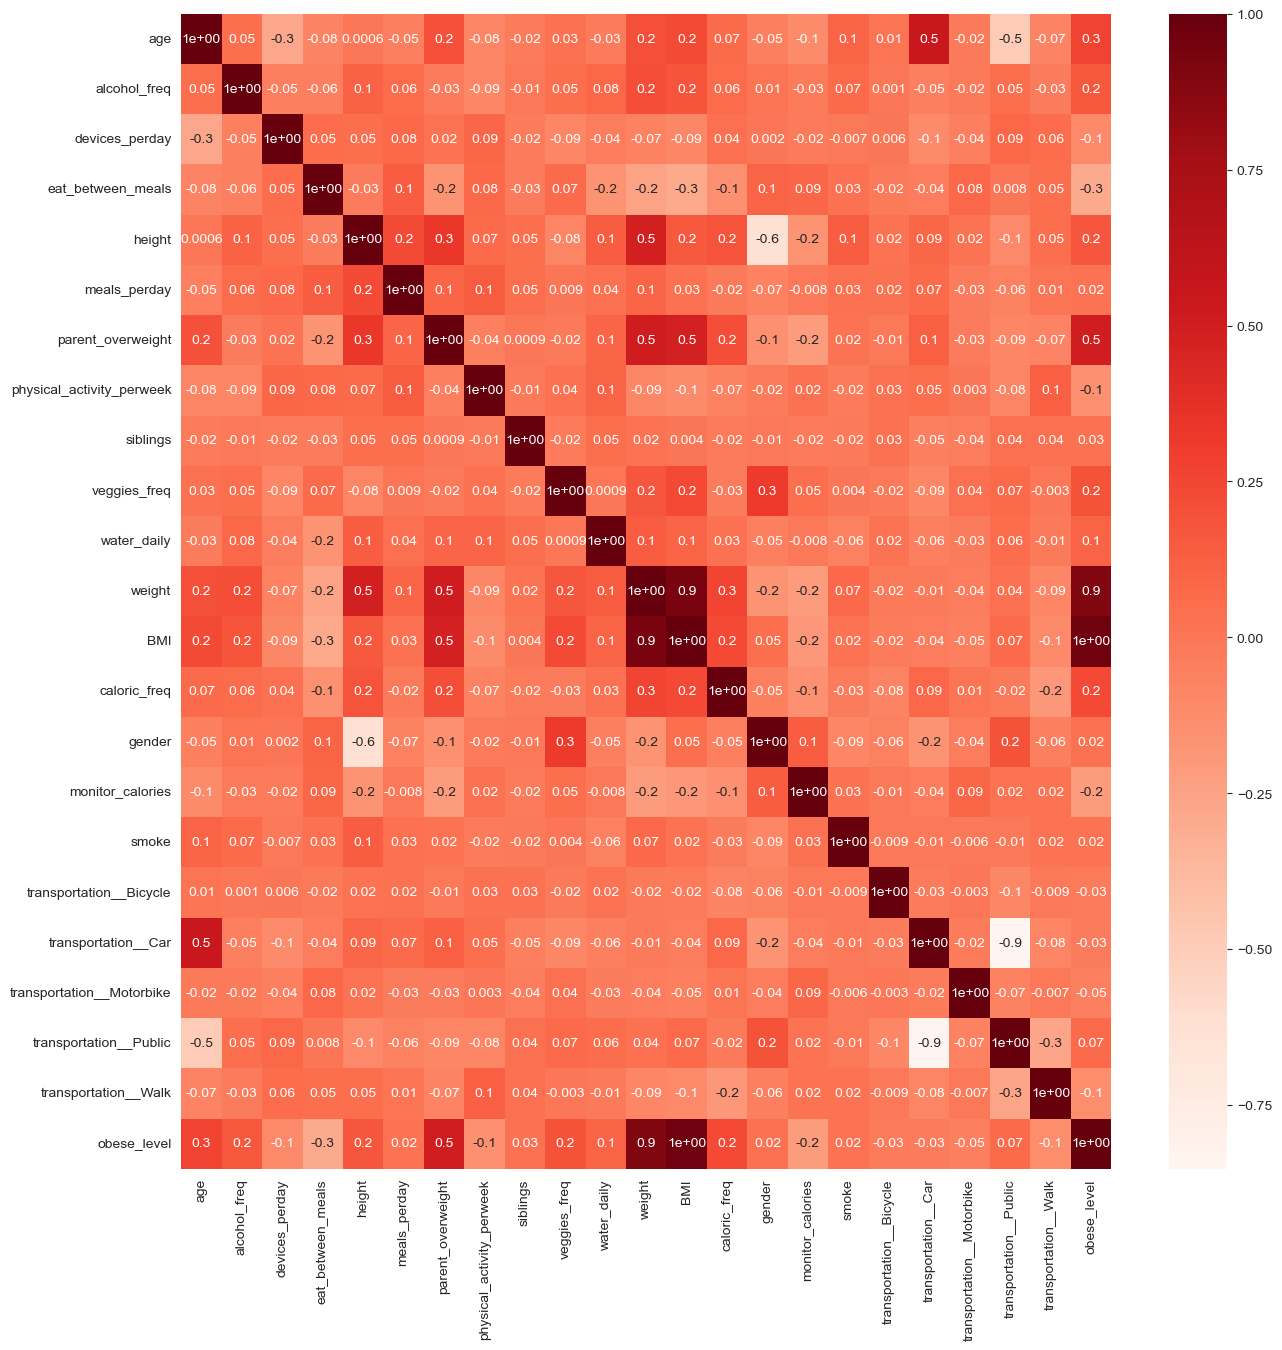

None

KENDALL correlation.


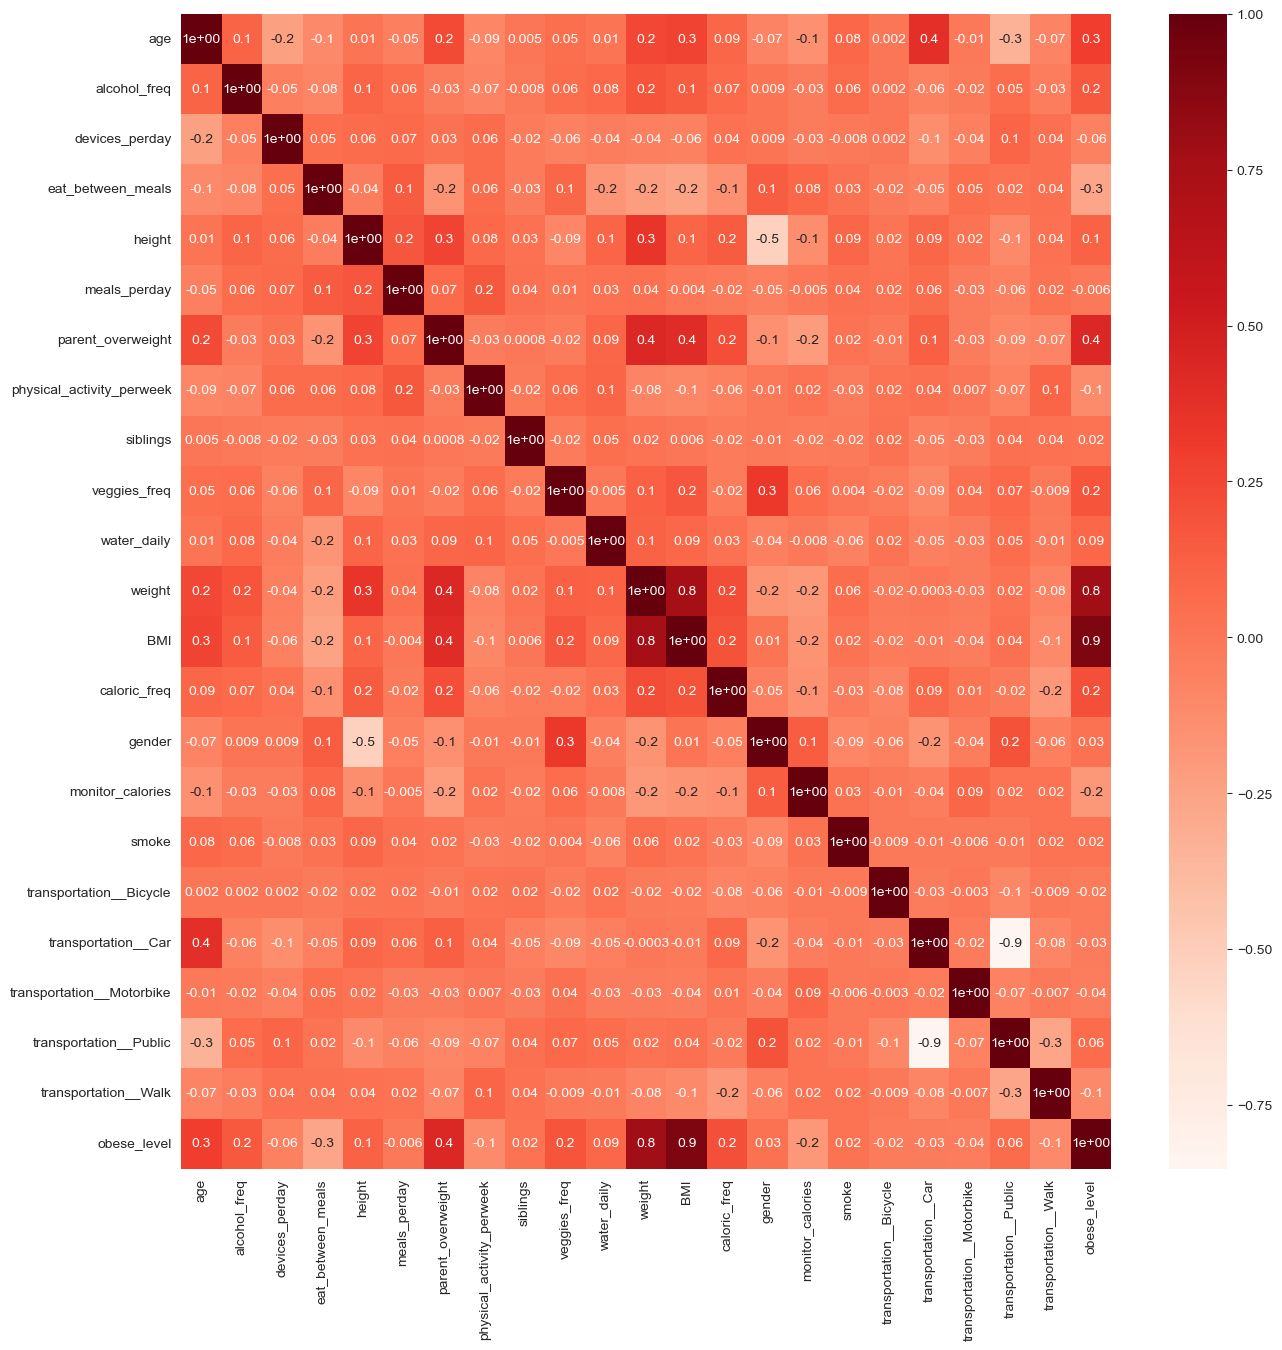

None

In [90]:
"""
We will be using a 'less than 0.15 correlation' striking method.
"""
compile_corr_dic = []

X_train=  pd.concat([X_train_imputed, y_train_encoded], axis=1)
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors= 'coerce').astype('float64')
    
def cor_heatmap(cor):
    plt.figure(figsize=(15,15))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
    
for corr_type in ['spearman', 'pearson', 'kendall']:
    cor_dic =filter_dic.copy()
    print(f'{corr_type.upper()} correlation.')
    X_train_corr = X_train.corr(method = corr_type)
    display(cor_heatmap(X_train_corr))

    # Adding a strike count
    for key in X_train_corr[X_train_corr['obese_level'].abs()< 0.15].index:
      cor_dic[key]='Yes'
    compile_corr_dic.append(cor_dic)


##### Chi Square

In [92]:
chi_square_dic =filter_dic.copy()

def TestIndependence(X,y,var,alpha=0.05, strike_active = False):        
    dfObserved = pd.crosstab(y,X) 
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p<alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
        if strike_active:
            chi_square_dic[var]= 'Yes'
    print(result)

for var in X_train_imputed:
    TestIndependence(X_train_imputed[var], y_train_encoded, var, strike_active= True)

age is IMPORTANT for Prediction
alcohol_freq is IMPORTANT for Prediction
devices_perday is IMPORTANT for Prediction
eat_between_meals is IMPORTANT for Prediction
height is IMPORTANT for Prediction
meals_perday is IMPORTANT for Prediction
parent_overweight is IMPORTANT for Prediction
physical_activity_perweek is IMPORTANT for Prediction
siblings is NOT an important predictor. (Discard siblings from model)
veggies_freq is IMPORTANT for Prediction
water_daily is IMPORTANT for Prediction
weight is IMPORTANT for Prediction
BMI is IMPORTANT for Prediction
caloric_freq is IMPORTANT for Prediction
gender is IMPORTANT for Prediction
monitor_calories is IMPORTANT for Prediction
smoke is IMPORTANT for Prediction
transportation__Bicycle is NOT an important predictor. (Discard transportation__Bicycle from model)
transportation__Car is IMPORTANT for Prediction
transportation__Motorbike is IMPORTANT for Prediction
transportation__Public is IMPORTANT for Prediction
transportation__Walk is IMPORTANT fo

#### Wrapper Methods

##### Recursive Feature Selection

In [94]:
# we will be using a decision tree classifier, since we are dealing with a multiclassifier model
rfe_dic= filter_dic.copy()
rfe = RFE(estimator = DecisionTreeClassifier(), n_features_to_select = 10)
rfe.fit_transform(X_train_imputed, y_train_clean)

selected_features = pd.Series(rfe.support_, index = X_train_imputed.columns)
for key in selected_features[selected_features == False].index:
    rfe_dic[key] ='Yes'
    
display(selected_features)
display(rfe.ranking_)


age                           True
alcohol_freq                 False
devices_perday               False
eat_between_meals             True
height                        True
meals_perday                  True
parent_overweight            False
physical_activity_perweek    False
siblings                      True
veggies_freq                 False
water_daily                  False
weight                        True
BMI                           True
caloric_freq                  True
gender                        True
monitor_calories             False
smoke                        False
transportation__Bicycle      False
transportation__Car           True
transportation__Motorbike    False
transportation__Public       False
transportation__Walk         False
dtype: bool

array([ 1, 10,  2,  1,  1,  1,  3,  5,  1, 11, 13,  1,  1,  1,  1,  6,  8,
       12,  1,  9,  4,  7])

#### Embedded Method - Lasso

[ 9.92194303e-02 -1.57914560e-02 -0.00000000e+00 -5.81856359e-02
  0.00000000e+00 -6.44564393e-03  1.52395256e-01 -8.11683210e-02
  6.16176199e-02 -5.00237450e-02  0.00000000e+00  1.19319968e-01
  2.48679358e+00  0.00000000e+00 -9.78232615e-04 -1.46032369e-02
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
  1.21774704e-01 -0.00000000e+00]


age                          0.099219
alcohol_freq                -0.015791
devices_perday              -0.000000
eat_between_meals           -0.058186
height                       0.000000
meals_perday                -0.006446
parent_overweight            0.152395
physical_activity_perweek   -0.081168
siblings                     0.061618
veggies_freq                -0.050024
water_daily                  0.000000
weight                       0.119320
BMI                          2.486794
caloric_freq                 0.000000
gender                      -0.000978
monitor_calories            -0.014603
smoke                       -0.000000
transportation__Bicycle     -0.000000
transportation__Car         -0.000000
transportation__Motorbike    0.000000
transportation__Public       0.121775
transportation__Walk        -0.000000
dtype: float64

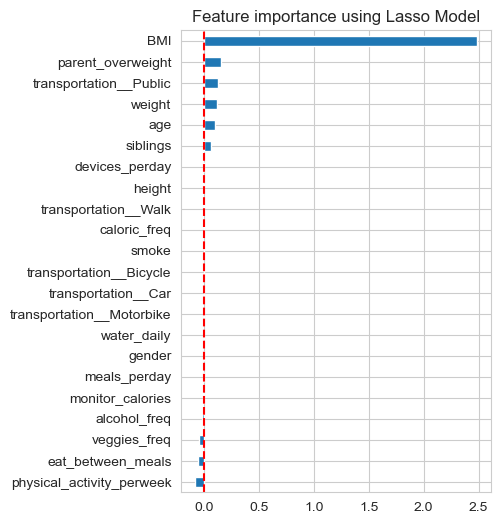

In [96]:
# Note: lasso only accepts non missing values. We will input missing values with the median for analysis purposes ? IDK rethink this later
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    #plt.figure(figsize=(8,10))
    plt.figure(figsize=(4,6))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()


reg_lasso = LassoCV()
reg_lasso.fit(X= X_train_imputed, y=y_train_clean)
reg_lasso.coef_
print(reg_lasso.coef_)

reg_lasso_coef = pd.Series(reg_lasso.coef_, index = X_train_median.columns)
display(reg_lasso_coef) # displaying Series with coeficients

plot_importance(reg_lasso_coef,'Lasso') # plotting, essentially """

#### Tree Ensembles

In [98]:
# Using Tree Ensembles for feature selection
clf_dic= filter_dic.copy()

clf = ExtraTreesClassifier(n_estimators=50)
clf = clf.fit(X_train_imputed, y_train_clean)

df_clf= pd.DataFrame([X_train_imputed.columns, clf.feature_importances_]).T.set_axis(['Variable', 'Score'], axis=1).sort_values(by= ['Score']).reset_index(drop = True)
display(df_clf)

for key in df_clf[:8]['Variable'].tolist():
    clf_dic[key] ='Yes'

#print(clf_dic)

,Variable,Score
0,transportation__Motorbike,0.000355
1,transportation__Bicycle,0.000563
2,smoke,0.003916
3,transportation__Walk,0.004193
4,monitor_calories,0.008662
5,siblings,0.018374
6,transportation__Car,0.018986
7,transportation__Public,0.020159
8,caloric_freq,0.023867
9,physical_activity_perweek,0.026912


In [100]:
# Conclusions
#We will be working with X_train_processed and X_val_processed from now on

df_corr = pd.DataFrame([univariate_dic, compile_corr_dic[0], compile_corr_dic[1], compile_corr_dic[2], chi_square_dic, rfe_dic, clf_dic]).T.set_axis(
    ['Variance', 'Spearman', 'Pearson', 'Kendall', 'Chi Square', 'Recursive Feat. El', 'Tree Ensembles'], axis=1)

df_corr['Total Strikes_percent']= round(df_corr[df_corr == 'Yes'].count(axis=1)*100/ df_corr.shape[1], 2)
df_corr.sort_values(by= ['Total Strikes_percent'], ascending= False, inplace= True)
"""
We will be dropping features with more than a 50% strike score; or with very low variability
"""
df_corr['Decision'] = 'Keep' # default param

df_corr.loc[(df_corr['Total Strikes_percent']>= 50), 'Decision'] = 'Drop'
df_corr.loc[df_corr['Variance'] == 'Absolutely Yes', 'Decision'] = 'Drop'

columns_to_drop= df_corr[df_corr['Decision']== 'Drop'].index.tolist()

print(columns_to_drop)
df_corr

['transportation__Bicycle', 'transportation__Motorbike', 'smoke', 'transportation__Walk', 'siblings', 'transportation__Public', 'physical_activity_perweek', 'transportation__Car', 'water_daily', 'devices_perday']


,Variance,Spearman,Pearson,Kendall,Chi Square,Recursive Feat. El,Tree Ensembles,Total Strikes_percent,Decision
transportation__Bicycle,Yes,Yes,Yes,Yes,Yes,Yes,Yes,100.00,Drop
transportation__Motorbike,Yes,Yes,Yes,Yes,No,Yes,Yes,85.71,Drop
smoke,Yes,Yes,Yes,Yes,No,Yes,Yes,85.71,Drop
transportation__Walk,Yes,Yes,Yes,Yes,No,Yes,Yes,85.71,Drop
siblings,No,Yes,Yes,Yes,Yes,No,Yes,71.43,Drop
transportation__Public,No,Yes,Yes,Yes,No,Yes,Yes,71.43,Drop
physical_activity_perweek,No,Yes,Yes,Yes,No,Yes,No,57.14,Drop
transportation__Car,No,Yes,Yes,Yes,No,No,Yes,57.14,Drop
water_daily,No,Yes,Yes,Yes,No,Yes,No,57.14,Drop
devices_perday,No,Yes,Yes,Yes,No,Yes,No,57.14,Drop


In [232]:
df_corr.tail(12)

,Variance,Spearman,Pearson,Kendall,Chi Square,Recursive Feat. El,Tree Ensembles,Total Strikes_percent,Decision
meals_perday,No,Yes,Yes,Yes,No,No,No,42.86,Keep
gender,No,Yes,Yes,Yes,No,No,No,42.86,Keep
monitor_calories,Yes,No,No,No,No,Yes,Yes,42.86,Keep
height,No,No,No,Yes,No,No,No,14.29,Keep
parent_overweight,No,No,No,No,No,Yes,No,14.29,Keep
alcohol_freq,No,No,No,No,No,Yes,No,14.29,Keep
caloric_freq,Yes,No,No,No,No,No,No,14.29,Keep
veggies_freq,No,No,No,No,No,Yes,No,14.29,Keep
age,No,No,No,No,No,No,No,0.00,Keep
BMI,No,No,No,No,No,No,No,0.00,Keep


In [102]:
X_train_processed = X_train_imputed.drop(columns_to_drop, axis = 1)
# VALIDATION
X_val_processed = X_val_imputed.drop(columns_to_drop, axis=1)

<a class="anchor" id="">

# 4 & 5. Model & Assess (Modelling and Assessment)

</a>

In [104]:
# From now on, we will moving on with the following variables
display(X_train_processed)
display(y_train_clean)
display(X_val_processed)
display(y_val_clean)


,age,alcohol_freq,eat_between_meals,height,meals_perday,parent_overweight,veggies_freq,weight,BMI,caloric_freq,gender,monitor_calories
id,,,,,,,,,,,,
372,3.666667,-1.0,1.0,-0.071429,0.0,-1.0,1.0,0.073620,0.092120,1.0,0.0,0.0
1195,0.333333,0.0,0.0,0.428571,0.0,0.0,0.0,0.760736,0.680501,1.0,0.0,0.0
75,-0.166667,0.0,1.0,-0.428571,1.0,0.0,1.0,-0.613497,-0.658092,1.0,1.0,0.0
1162,0.666667,0.0,0.0,0.428571,0.0,0.0,0.0,0.858896,0.793805,0.0,0.0,0.0
475,-0.666667,0.0,1.0,0.000000,1.0,-1.0,-1.0,-0.809816,-1.031224,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1368,1.833333,-1.0,0.0,0.000000,-1.0,0.0,1.0,0.490798,0.577250,1.0,0.0,0.0
1160,1.666667,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.490798,0.614133,1.0,0.0,0.0
708,-0.333333,0.0,0.0,0.285714,-1.0,0.0,0.0,-0.122699,-0.288442,1.0,1.0,0.0


id
372     4.0
1195    6.0
75      2.0
1162    6.0
475     1.0
       ... 
1368    6.0
1160    6.0
708     3.0
641     3.0
487     1.0
Name: obese_level, Length: 1125, dtype: float64

,age,alcohol_freq,eat_between_meals,height,meals_perday,parent_overweight,veggies_freq,weight,BMI,caloric_freq,gender,monitor_calories
id,,,,,,,,,,,,
713,0.000000,0.0,0.0,-0.071429,0.0,0.0,0.0,-0.196319,-0.245653,1.0,0.0,0.0
1223,0.166667,0.0,0.0,0.500000,0.0,0.0,1.0,0.883436,0.784363,1.0,0.0,0.0
1167,1.333333,0.0,0.0,0.285714,0.0,0.0,1.0,0.907975,0.928594,1.0,0.0,0.0
1221,1.500000,-1.0,0.0,-0.071429,-1.0,0.0,1.0,0.490798,0.614133,1.0,0.0,0.0
298,-0.833333,-1.0,1.0,0.357143,0.0,-1.0,1.0,-0.319018,-0.543243,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
821,0.166667,0.0,0.0,1.071429,-1.0,0.0,-1.0,0.319018,-0.086155,1.0,0.0,0.0
1393,0.500000,0.0,0.0,-0.428571,0.0,0.0,1.0,0.539877,0.873913,1.0,1.0,0.0
1461,-0.666667,0.0,0.0,0.071429,0.0,0.0,1.0,1.104294,1.290925,1.0,1.0,0.0


id
713     3.0
1223    6.0
1167    6.0
1221    6.0
298     2.0
       ... 
821     4.0
1393    7.0
1461    7.0
1585    7.0
338     2.0
Name: obese_level, Length: 483, dtype: float64

<img src="image/step4.png" style="height:60px">

### 4.1. Model Selection

In this section you should take the time to train different predictive algorithms with the data that got to this stage and **use the approppriate model assessment metrics to decide which model you think is the best to address your problem**.

**You are expected to present on your report the model performances of the different algorithms that you tested and discuss what informed your choice for a specific algorithm**

Model Choices
- Decision Tree Classifier
- Multi Layer Perceptron
- Linear Support Vector Classifier
- K-Nearest Neighbors Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- Bagging Classifier
- Adaboost Classifier

<p> We are dealing with a multiclassification instance </p> 
<p> Functioning: fitting model to X_train and y_train; apply grid search to define best possible parameters </p> 


In [106]:
# Decision Tree Classifier
Decision_Tree_Classifier = DecisionTreeClassifier(criterion = 'gini', max_depth = 1, max_leaf_nodes = 10, min_samples_split = 2)
Decision_Tree_Classifier.fit(X_train_processed, y_train_clean)
parameters_Decision_Tree_Classifier =  {'criterion':['log_loss', 'gini', 'entropy'],'max_depth':np.arange(1,10)[0::2].tolist(),'min_samples_split':np.arange(2,11)[0::2].tolist(),'max_leaf_nodes':np.arange(2,10)[0::2].tolist()}

In [112]:
# Multilayer Perceptron Classifier
Multilayer_Perceptron_Classifier = MLP(activation= "relu", alpha= 0.0001, hidden_layer_sizes= (100,), learning_rate= "constant", solver= "adam")
Multilayer_Perceptron_Classifier.fit(X_train_processed, y_train_clean)
parameters_Multilayer_Perceptron_Classifier = {'activation': ['tanh', 'relu'],'solver': ['sgd', 'adam'],'alpha': [0.0001, 0.025, 0.05],'learning_rate': ['constant','adaptive'],}

In [114]:
# Linear Support Vector Classifier
#While primarily a binary classifier, scikit-learn automatically handles multiclass classification using the one-vs-rest strategy.
"""
The One-vs-Rest (OvR) strategy, also known as One-vs-All (OvA):
is a heuristic method used to extend binary classification algorithms to multi-class classification problems;
This approach involves splitting a multi-class classification problem into multiple binary classification problems,
where each class is treated as a separate binary classification task against all other classes

#Determines the multi-class strategy if y contains more than two classes. "ovr" trains n_classes one-vs-rest classifiers

"""
Linear_Support_Vector_Classifier = LinearSVC(penalty='l2', loss='squared_hinge', C=1.0, multi_class='ovr', max_iter = 500)
Linear_Support_Vector_Classifier.fit(X_train_processed, y_train_clean)
parameters_Linear_Support_Vector_Classifier = {'penalty': ['l1', 'l2'], 'loss':['squared_hinge'],'C': [0.1, 1, 10, 100, 1000], 'multi_class':['ovr'], 'max_iter' :[500]}


In [116]:
# K-Nearest Neighbors Classifier
KNeighbors_Classifier = KNeighborsClassifier(n_neighbors = 5, weights= 'uniform', algorithm = 'ball_tree', leaf_size = 30)
KNeighbors_Classifier.fit(X_train_processed, y_train_clean)
parameters_KNeighborsClassifier= {'n_neighbors' : np.arange(2,20)[0::2].tolist(), 'weights': ['uniform', 'distance'], 'algorithm' : ['ball_tree', 'kd_tree', 'brute'], 'leaf_size' : np.arange(5,50)[0::5].tolist()}

In [118]:
# Random Forest Classifier
RandomForest_Classifier = RandomForestClassifier(n_estimators = 100, criterion = 'gini', max_depth=2, random_state=42, bootstrap = True)
RandomForest_Classifier.fit(X_train_processed, y_train_clean)
parameters_RandomForestClassifier= {'n_estimators' : [50, 100, 150], 'criterion': ['gini', 'entropy', 'log_loss'], 'max_depth': [1, 2, 4, 6, 8], 'random_state': [0, 1], 'bootstrap': [True, False]}

In [172]:
# Gradient Boosting Classifier
GradientBoosting_Classifier = GradientBoostingClassifier(loss = 'log_loss', learning_rate = 0.1, n_estimators = 100, criterion = 'friedman_mse')
GradientBoosting_Classifier.fit(X_train_processed, y_train_clean)
parameters_GradientBoostingClassifier = {'loss' : ['log_loss', 'exponential'], 'learning_rate': [0.1, 0.2, 0.5], 'n_estimators': [100, 150,200], 'criterion': ['friedman_mse', 'squared_error']}

In [175]:
# Bagging Classifier
# Base estimator as decision trees
Bagging_Classifier = BaggingClassifier(n_estimators = 10, max_features= 1.0)
Bagging_Classifier.fit(X_train_processed, y_train_clean)
parameters_Bagging_Classifier = {'n_estimators': [100, 150, 200], 'max_features': [0.25, 0.5, 0.75]}

In [124]:
# AdaBoost Classifier
AdaBoost_Classifier = AdaBoostClassifier(estimator=None, n_estimators=50, learning_rate=1.0, random_state= 42)
AdaBoost_Classifier.fit(X_train_processed, y_train_clean)
parameters_AdaBoostClassifier= {'n_estimators': [25, 50, 100, 150], 'learning_rate' : [0.25, 0.5, 1.0]}

### 4.2. Model Optimization

After selecting the best algorithm (set of algorithms), you can try to optimize the performance of your model by fiddling with the algorithms' hyper-parameters and select the options that result on the best overall performance.

Possible ways of doing this can be through:
1. [GridSearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
2. [RandomSearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

**While you are not required to show the results of all combinations of hyperparameters that you tried, you should at least discuss the what were the possible combinations used and which of them resulted in your best performance**

In [150]:
Best_Decision_Tree_Classifier = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = parameters_Decision_Tree_Classifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_Decision_Tree_Classifier.best_params_)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


{'criterion': 'log_loss',
 'max_depth': 1,
 'max_leaf_nodes': 2,
 'min_samples_split': 2}

In [124]:
Best_Multilayer_Perceptron_Classifier = GridSearchCV(estimator = MLP(), param_grid = parameters_Multilayer_Perceptron_Classifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_Multilayer_Perceptron_Classifier.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


{'activation': 'tanh',
 'alpha': 0.0001,
 'learning_rate': 'constant',
 'solver': 'sgd'}

In [125]:
Best_Linear_Support_Vector_Classifier = GridSearchCV(estimator = LinearSVC(), param_grid = parameters_Linear_Support_Vector_Classifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_Linear_Support_Vector_Classifier.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


{'C': 0.1,
 'loss': 'squared_hinge',
 'max_iter': 500,
 'multi_class': 'ovr',
 'penalty': 'l1'}

In [126]:
Best_KNeighbors_Classifier = GridSearchCV(estimator = KNeighborsClassifier(), param_grid = parameters_KNeighborsClassifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_KNeighbors_Classifier.best_params_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


{'algorithm': 'ball_tree',
 'leaf_size': 5,
 'n_neighbors': 2,
 'weights': 'uniform'}

In [127]:
Best_RandomForest_Classifier = GridSearchCV(estimator = RandomForestClassifier(), param_grid = parameters_RandomForestClassifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_RandomForest_Classifier.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 1,
 'n_estimators': 50,
 'random_state': 0}

In [174]:
Best_GradientBoostingClassifier = GridSearchCV(estimator = GradientBoostingClassifier(), param_grid = parameters_GradientBoostingClassifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_GradientBoostingClassifier.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


{'criterion': 'friedman_mse',
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'n_estimators': 100}

In [96]:
Best_BaggingClassifier = GridSearchCV(estimator = BaggingClassifier(), param_grid = parameters_Bagging_Classifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_BaggingClassifier.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'max_features': 0.25, 'n_estimators': 25}

In [138]:
Best_AdaBoostClassifier = GridSearchCV(estimator = AdaBoostClassifier(), param_grid = parameters_AdaBoostClassifier, scoring = 'f1', verbose = True).fit(X_train_processed, y_train_clean)
display(Best_AdaBoostClassifier.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'learning_rate': 0.25, 'n_estimators': 25}

In [178]:
"""
In order to preserve good computing efforts, it was decided as a best practice to save the results, to avoid this computationally expensive procdeure.
"""
Best_Decision_Tree_Classifier = DecisionTreeClassifier(criterion= 'log_loss', max_depth= 1, max_leaf_nodes= 2, min_samples_split= 2).fit(X_train_processed, y_train_clean)
Best_Multilayer_Perceptron_Classifier= MLP(activation='tanh', alpha= 0.0001, learning_rate= 'constant', solver= 'sgd').fit(X_train_processed, y_train_clean)
Best_Linear_Support_Vector_Classifier= LinearSVC(C= 0.1, loss= 'squared_hinge',max_iter = 500, multi_class= 'ovr', penalty= 'l1').fit(X_train_processed, y_train_clean)
Best_KNeighbors_Classifier= KNeighborsClassifier(algorithm= 'ball_tree', leaf_size= 5, n_neighbors= 2, weights= 'uniform').fit(X_train_processed, y_train_clean)
Best_RandomForest_Classifier= RandomForestClassifier(bootstrap= True, criterion= 'gini', max_depth= 1, n_estimators= 50, random_state= 0).fit(X_train_processed, y_train_clean)
Best_GradientBoostingClassifier= GradientBoostingClassifier(criterion= 'friedman_mse', learning_rate= 0.1, loss= 'log_loss', n_estimators= 100).fit(X_train_processed, y_train_clean)
Best_BaggingClassifier= BaggingClassifier(max_features= 0.25, n_estimators= 25).fit(X_train_processed, y_train_clean)
Best_AdaBoostClassifier = AdaBoostClassifier(learning_rate= 0.25, n_estimators= 25).fit(X_train_processed, y_train_clean)


In [180]:
# Resuming the Best models, obtained from grid search
list_of_models = [Best_Decision_Tree_Classifier, Best_Multilayer_Perceptron_Classifier, Best_Linear_Support_Vector_Classifier, Best_KNeighbors_Classifier,
                 Best_RandomForest_Classifier, Best_GradientBoostingClassifier, Best_BaggingClassifier, Best_AdaBoostClassifier]
labels = ['Decision_Tree_Classifier', 'Multilayer_Perceptron_Classifier','Linear_Support_Vector_Classifier', 'KNeighbors_Classifier',
                'RandomForest_Classifier', 'GradientBoostingClassifier', 'BaggingClassifier', 'AdaBoostClassifier']
# Prediction results on training data
def pred_trainscore(list_of_models):

    f1, balanced_accuracy, precision, recall = {}, {}, {}, {}

    for model in list_of_models:
        predictions_train = model.predict(X_train_processed)

        balanced_accuracy[model] = balanced_accuracy_score(y_train_clean, predictions_train)

        f1[model] = f1_score(y_train_clean, predictions_train, average='weighted')

        precision[model] = precision_score(y_train_clean, predictions_train, average='weighted', zero_division=0)

        recall[model] = recall_score(y_train_clean, predictions_train, average='weighted', zero_division=0)

        results = pd.DataFrame.from_dict({'F1 Score': f1, 'Balanced Accuracy': balanced_accuracy, 'Precision': precision, 'Recall': recall})
    results= results.set_axis(labels, axis =0)
    return results

# Prediction results on validation data
def pred_valscore(list_of_models):

    f1, balanced_accuracy, precision, recall = {}, {}, {}, {}

    for model in list_of_models:
        predictions_val = model.predict(X_val_processed)

        balanced_accuracy[model] = balanced_accuracy_score(y_val_clean, predictions_val)

        f1[model] = f1_score(y_val_clean, predictions_val, average='weighted')

        precision[model] = precision_score(y_val_clean, predictions_val, average='weighted', zero_division=0)

        recall[model] = recall_score(y_val_clean, predictions_val, average='weighted', zero_division=0)

        results = pd.DataFrame.from_dict({'F1 Score': f1, 'Balanced Accuracy': balanced_accuracy, 'Precision': precision, 'Recall': recall})
    results= results.set_axis(labels, axis =0)

    return results

print('-------- Prediction Results on Training Data --------')
display(pred_trainscore(list_of_models))
print('-------- Prediction Results on Validation Data --------')
display(pred_valscore(list_of_models))

-------- Prediction Results on Training Data --------


,F1 Score,Balanced Accuracy,Precision,Recall
Decision_Tree_Classifier,0.145117,0.284046,0.095743,0.304889
Multilayer_Perceptron_Classifier,0.677089,0.696175,0.690035,0.695111
Linear_Support_Vector_Classifier,0.697592,0.720363,0.710521,0.716444
KNeighbors_Classifier,0.939148,0.939451,0.941362,0.938667
RandomForest_Classifier,0.652055,0.653788,0.692363,0.661333
GradientBoostingClassifier,0.999111,0.999072,0.999117,0.999111
BaggingClassifier,0.991070,0.991098,0.991144,0.991111
AdaBoostClassifier,0.284300,0.344662,0.237497,0.363556


-------- Prediction Results on Validation Data --------


,F1 Score,Balanced Accuracy,Precision,Recall
Decision_Tree_Classifier,0.143174,0.279686,0.094575,0.300207
Multilayer_Perceptron_Classifier,0.633540,0.658255,0.633698,0.658385
Linear_Support_Vector_Classifier,0.682351,0.703361,0.688163,0.699793
KNeighbors_Classifier,0.829172,0.828767,0.838014,0.828157
RandomForest_Classifier,0.640745,0.635001,0.674705,0.645963
GradientBoostingClassifier,0.952224,0.951670,0.952952,0.952381
BaggingClassifier,0.954435,0.953525,0.954693,0.954451
AdaBoostClassifier,0.293053,0.356354,0.247055,0.374741


In [214]:
# Final model assesment
# Best:
final_model = GradientBoostingClassifier(criterion= 'friedman_mse', 
                                     learning_rate= 0.1, loss= 'log_loss', n_estimators= 100) 
final_model.fit(X_train_processed, y_train_clean)


GradientBoostingClassifier()

In [215]:
kf = KFold(n_splits = 10,random_state = 42, shuffle = True)
rkf = RepeatedKFold(n_splits = 5, n_repeats = 4,random_state = 42)

def simple_split_f1(X, y, model):
    y_pred = model.predict(X)
    return f1_score(y, y_pred, average='weighted')
    
def run_model(X,y, model):
    return model.fit(X, y)

def evaluate_model(model,X,y,pred):
    return model.score(X,y), f1_score(y,pred, average= 'weighted')
    
def avg_scores(method,X,y, model, flag = False): # flag indicates printing statements
    score_train = []
    score_test = []
    f1_train = []
    f1_test = []
    for train_index, test_index in method.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
        value_train = evaluate_model(model, X_train, y_train, pred_train)
        value_test = evaluate_model(model,X_test,y_test,pred_test)
        score_train.append(value_train[0])
        score_test.append(value_test[0])
        f1_train.append(value_train[1])
        f1_test.append(value_test[1])
    if flag:
        print(f'----- {method} APPLIED -----')
        print('Train score:', np.mean(score_train))
        print('Test score:', np.mean(score_test))
        print('Train f1:', np.mean(f1_train))
        print('Test f1:', np.mean(f1_test))
        print()

    # Also returns a DataFrame with f1_train and f1_test scores
    return pd.DataFrame([np.mean(f1_train), np.mean(f1_test)]).T.set_axis(['Train F1 Score', 'Test F1 Score'], axis=1)

In [218]:
# Simple Split
final_model_train_f1 = simple_split_f1(X_train_processed, y_train_clean, final_model)
final_model_val_f1 = simple_split_f1(X_val_processed, y_val_clean, final_model)
df_final_f1= pd.DataFrame([final_model_train_f1, final_model_train_f1]).T.set_axis(['Train F1 Score', 'Test F1 Score'], axis=1)


# K-Fold Method
final_model_kf = avg_scores(kf,X_train_processed, y_train_clean, final_model, True)

# Repeated K_fold
final_model_rkf = avg_scores(rkf, X_train_processed, y_train_clean, final_model, True)

df_final_model = pd.concat([df_final_f1, final_model_kf, final_model_rkf]).set_axis(['Simple Split', 'K-Fold', 'Repeated K-Fold'], axis=0)
display(df_final_model)

----- KFold(n_splits=10, random_state=42, shuffle=True) APPLIED -----
Train score: 0.9991111596674067
Test score: 0.9991150442477876
Train f1: 0.9991111052767263
Test f1: 0.9991117452515074

----- RepeatedKFold(n_repeats=4, n_splits=5, random_state=42) APPLIED -----
Train score: 0.9991111111111112
Test score: 0.999111111111111
Train f1: 0.9991110373956819
Test f1: 0.999109856115011



,Train F1 Score,Test F1 Score
Simple Split,0.999111,0.999111
K-Fold,0.999111,0.999112
Repeated K-Fold,0.999111,0.999110


<a class="anchor" id="">

# 5. Deploy

</a>

<img src="image/step5.png" style="height:60px">

### 5.0 Training a final model

You used the previous steps of modelling and assessment to determine what would be best strategies when it comes to preprocessing, scaling, feature selection, algorithm and hyper-parameters you could find. 

**By this stage, all of those choices were already made**. For that reason, a split between training and validation is no longer necessary. **A good practice** would be to take the initial data and train a final model with all of the labeled data that you have available.

**Everything is figured by this stage**, so, on a first level all you need to do is replicate the exact preprocessing, scaling and feature selection decisions you made before.<br>
When it comes to the final model, all you have to do is creeate a new instance of your best algorithm with the best parameters that you uncovered (no need to try all algorithms and hyper-parameters again).

### 5.1. Import and Transform your test data

Remember, the test data does not have the `outcome` variable.

In [220]:
# Preprocessing accordingly the test segment
test_beta = test.copy()
test_beta.drop(['marrital_status', 'region'], axis = 1, inplace= True) 
test_beta['BMI'] = test_beta['weight'] / test_beta['height']**2

# VALIDATION Applying transformations to test
test_encoded= test_beta.copy()
# Transformation 1- Bivariate columns
for col in boolean_cols:
    bool_set(test_encoded, col)
    
# Transformation 2 -Assigning gender to boolean var
test_encoded.loc[test_encoded['gender'] =='Female', 'gender'] = 1
test_encoded.loc[test_encoded['gender'] =='Male', 'gender'] = 0

# Transformation 3 - Encoding categorical variables into ordinal variables
test_encoded = ordinal_encoder_ranks(test_encoded)

# Transformation 4- Encoding the transformation column into dummy variables

dummy_var_transport_test= pd.get_dummies(test_encoded['transportation'], prefix ='transportation_') # fitting dummies to train_test
test_encoded= pd.concat([test_encoded.drop('transportation', axis =1), dummy_var_transport_test], axis =1)
'''
Important note: applying a reindex to make sure all columns got passed accordingly in the dummy segment
'''
test_encoded= test_encoded.reindex(columns = X_train_encoded.columns, fill_value=0)
print('----- Test Encoded -----')
display(test_encoded)

# Transformation 5 X_val dtype transformation
test_encoded = dtype_transformation(test_encoded)

test_scaled_rbst = robust_scaler.transform(test_encoded[rbst_scaler_cols])
test_scaled_rbst = pd.DataFrame(test_scaled_rbst, columns=rbst_scaler_cols).set_index(test_encoded.index)

#Combining into a single dataframe
test_scaled = pd.concat([test_scaled_rbst, test_encoded.drop(rbst_scaler_cols, axis =1)], axis =1)
print('----- Test Scaled -----')
display(test_scaled)

# Outlier correction.

# Missing value treatment
test_imputed= pd.DataFrame(imputer_Xtrain.transform(test_scaled), index= test_scaled.index,
                                   columns = test_scaled.columns)
# Feat. Engineering
test_processed = test_imputed.drop(columns_to_drop, axis=1)

----- Test Encoded -----


,age,alcohol_freq,caloric_freq,devices_perday,eat_between_meals,gender,height,meals_perday,monitor_calories,parent_overweight,...,smoke,veggies_freq,water_daily,weight,BMI,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
1612,21.0,1.0,0,1.0,1.0,1,1.52,3.0,1,1,...,1,2.0,3.0,56.0,24.238227,0,False,False,True,False
1613,29.0,1.0,1,1.0,1.0,0,1.62,3.0,0,0,...,0,1.0,2.0,53.0,20.195092,0,True,False,False,False
1614,23.0,1.0,NaN,1.0,1.0,1,1.50,3.0,0,1,...,0,2.0,2.0,NaN,NaN,0,False,True,False,False
1615,22.0,0.0,1,2.0,1.0,0,1.72,3.0,0,1,...,0,1.0,2.0,68.0,22.985398,0,False,False,True,False
1616,26.0,1.0,1,3.0,2.0,0,1.85,3.0,0,1,...,0,2.0,3.0,105.0,30.679328,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,26.0,1.0,1,1.0,1.0,1,1.63,3.0,0,1,...,0,2.0,3.0,111.0,41.778012,0,False,False,True,False
2108,26.0,1.0,1,2.0,1.0,1,1.62,3.0,0,1,...,0,2.0,2.0,105.0,40.009145,0,False,False,True,False
2109,26.0,1.0,1,1.0,1.0,1,1.63,3.0,0,1,...,0,2.0,2.0,108.0,40.648877,0,False,False,True,False


----- Test Scaled -----


,age,alcohol_freq,devices_perday,eat_between_meals,height,meals_perday,parent_overweight,physical_activity_perweek,siblings,veggies_freq,...,BMI,caloric_freq,gender,monitor_calories,smoke,transportation__Bicycle,transportation__Car,transportation__Motorbike,transportation__Public,transportation__Walk
id,,,,,,,,,,,,,,,,,,,,,
1612,-0.333333,0.0,-1.0,0.0,-1.357143,0.0,0.0,2.0,0.500000,1.0,...,-0.397698,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1613,1.000000,0.0,-1.0,0.0,-0.642857,0.0,-1.0,NaN,0.500000,0.0,...,-0.756495,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1614,0.000000,0.0,-1.0,0.0,-1.500000,0.0,0.0,0.0,0.166667,1.0,...,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1615,-0.166667,-1.0,0.0,0.0,0.071429,0.0,0.0,0.0,-0.166667,0.0,...,-0.508877,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1616,0.500000,0.0,1.0,1.0,1.000000,0.0,0.0,1.0,-0.166667,1.0,...,0.173900,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,0.500000,0.0,-1.0,0.0,-0.571429,0.0,0.0,NaN,0.500000,1.0,...,1.158822,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2108,0.500000,0.0,0.0,0.0,-0.642857,0.0,0.0,NaN,0.500000,1.0,...,1.001849,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2109,0.500000,0.0,-1.0,0.0,-0.571429,0.0,0.0,NaN,-0.166667,1.0,...,1.058620,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 5.2. Obtain Predictions on the test data from your final model

In [222]:
# Model Fit
test_processed['Predict'] = final_model.predict(test_processed)
print('----- Model Fitted Predictions -----')
display(test_processed)

----- Model Fitted Predictions -----


,age,alcohol_freq,eat_between_meals,height,meals_perday,parent_overweight,veggies_freq,weight,BMI,caloric_freq,gender,monitor_calories,Predict
id,,,,,,,,,,,,,
1612,-0.333333,0.0,0.0,-1.357143,0.0,0.0,1.0,-0.662577,-0.397698,0.0,1.0,1.0,2.0
1613,1.000000,0.0,0.0,-0.642857,0.0,-1.0,0.0,-0.736196,-0.756495,1.0,0.0,0.0,2.0
1614,0.000000,0.0,0.0,-1.500000,0.0,0.0,1.0,0.687117,1.158822,1.0,1.0,0.0,7.0
1615,-0.166667,-1.0,0.0,0.071429,0.0,0.0,0.0,-0.368098,-0.508877,1.0,0.0,0.0,2.0
1616,0.500000,0.0,1.0,1.000000,0.0,0.0,1.0,0.539877,0.173900,1.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,0.500000,0.0,0.0,-0.571429,0.0,0.0,1.0,0.687117,1.158822,1.0,1.0,0.0,7.0
2108,0.500000,0.0,0.0,-0.642857,0.0,0.0,1.0,0.539877,1.001849,1.0,1.0,0.0,7.0
2109,0.500000,0.0,0.0,-0.571429,0.0,0.0,1.0,0.613497,1.058620,1.0,1.0,0.0,7.0


### 5.3. Create a Dataframe containing the index of each row and its intended prediction and export it to a csv file

In [224]:
# Reverse encodings
def reverse_encodings_out(row):
    encoding_target_variable= {1.0: 'Insufficient_Weight', 2.0: 'Normal_Weight', 3.0: 'Overweight_Level_I',
        4.0:'Overweight_Level_II', 5.0:'Obesity_Type_I', 6.0:'Obesity_Type_II', 7.0: 'Obesity_Type_III'}
    return encoding_target_variable[row]

df_kaggle = pd.DataFrame(test_processed['Predict'].apply(reverse_encodings_out))
df_kaggle

,Predict
id,
1612,Normal_Weight
1613,Normal_Weight
1614,Obesity_Type_III
1615,Normal_Weight
1616,Obesity_Type_I
...,...
2107,Obesity_Type_III
2108,Obesity_Type_III
2109,Obesity_Type_III


In [226]:
df_kaggle.to_csv('Group16__Version13.csv', index= True)

Submit the csv file to Kaggle to obtain the model performance of your model on the test data.